# Test Fox (`fox.ckpt`)

Evaluates the released model on the 100 simulated test datasets in `test_data/Datasets/` (made with the current
simulator, so without lost-gene leaves), pre-encoded in `test_data/fox_data/`
(`python training/pre_encoder.py --src test_data/Datasets --dst test_data/fox_data`). Then: an independent treeducken test set (Fox vs AmoCoala, error vs tree size), the cockroach /
*Blattabacterium* real-data test, robustness to alignment length and row-order invariance. Extras at the end:
Fox vs AmoCoala on the AsymmeTree test set, and the *Heliconius* real-data test.

The previous model and its notebook are in `old/`.

In [30]:
import sys, os

import torch
import torch.nn.functional as F
import pandas as pd

from fox import load_model

CKPT_PATH = "fox.ckpt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = load_model(CKPT_PATH, str(device))   # reads the architecture from the checkpoint
ckpt = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)
print(f"Model loaded: epoch {ckpt.get('epoch', -1) + 1}, val loss {ckpt.get('val_loss', float('nan')):.6f}, "
      f"{sum(p.numel() for p in model.parameters()):,} params")

Model loaded: epoch 23, val loss 0.004124, 21,454,349 params


In [31]:
# ── Encoding utilities: the same functions training uses (fox/encoding.py) ─────
import re
from fox.encoding import (AMINO_ACIDS, AA_TO_INDEX, UNK_ID, PAD_ID, MAX_SEQ_LEN, JC_MAX_P,
                          encode_sequence, jukes_cantor_dist)   # 20-state protein Jukes-Cantor

def load_pt(path):
    s = torch.load(path, map_location="cpu", weights_only=False)
    if "host_msa" in s:
        return s["host_msa"], s["para_msa"], s["host_dist"], s["para_dist"], s["mappings"], s.get("labels")
    host_msas = s["host_msas"]
    para_msas = s["parasite_msas"]
    h_idx = {n: i for i, n in enumerate(host_msas)}
    p_idx = {n: i for i, n in enumerate(para_msas)}
    host_tok = torch.stack([encode_sequence(seq) for seq in host_msas.values()])
    para_tok = torch.stack([encode_sequence(seq) for seq in para_msas.values()])
    raw_mappings = s["mappings"]
    if raw_mappings and isinstance(raw_mappings[0], (tuple, list)) and isinstance(raw_mappings[0][0], str):
        mappings = [(h_idx[h], p_idx[p]) for p, h in raw_mappings if p in p_idx and h in h_idx]
    else:
        mappings = raw_mappings
    labels = s.get("event_frequencies") if s.get("event_frequencies") is not None else s.get("labels")
    return host_tok, para_tok, jukes_cantor_dist(host_tok), jukes_cantor_dist(para_tok), mappings, labels

_INDEX_TO_AA = {i: aa for aa, i in AA_TO_INDEX.items()}

def _decode(tok):
    return "".join(_INDEX_TO_AA.get(int(t), "X") for t in tok if int(t) != PAD_ID)

def load_as_strings(path):
    """A .pt as {host_msas, parasite_msas: {name: sequence}, mappings: [(parasite, host)], event_frequencies}.

    Pre-encoded files only store tokens: they are decoded back to sequences, with leaves named H<i> / P<j>
    after their row, so the sections below can truncate or reorder sequences by name."""
    s = torch.load(path, map_location="cpu", weights_only=False)
    if "host_msas" in s:
        return s
    host = {f"H{i}": _decode(t) for i, t in enumerate(s["host_msa"])}
    para = {f"P{j}": _decode(t) for j, t in enumerate(s["para_msa"])}
    return {"host_msas": host, "parasite_msas": para,
            "mappings": [(f"P{p}", f"H{h}") for h, p in s["mappings"]],
            "event_frequencies": s["labels"]}

_FREQ_KEYS = {"Speciation_freq": "Speciation", "HGT_freq": "HGT",
              "Loss_freq": "Loss", "Duplication_freq": "Duplication", "Sim_time": "Sim_time"}

def parse_tgl(path):
    result = dict(host_tree=None, para_tree=None,
                  host_msa={}, para_msa={},
                  distribution=[], event_freqs={})
    section, in_aln = None, False
    with open(path) as f:
        for line in f:
            s = line.strip()
            if s.startswith("BEGIN HOST;"):
                section, in_aln = "HOST", False; continue
            elif s.startswith("BEGIN PARASITE;"):
                section, in_aln = "PARA", False; continue
            elif s.startswith("BEGIN DISTRIBUTION;"):
                section = "DIST"; continue
            elif s in ("ENDBLOCK;", "END;"):
                section, in_aln = None, False; continue
            if section in ("HOST", "PARA"):
                m = re.match(r"TREE \* \S+ = (.+)", s)
                if m:
                    key = "host_tree" if section == "HOST" else "para_tree"
                    result[key] = m.group(1).rstrip(";"); continue
                if s.startswith("ALIGNMENT"):
                    in_aln = True; continue
                if in_aln and s == "'":
                    in_aln = False; continue
                if in_aln:
                    parts = s.split()
                    if len(parts) == 2:
                        d = result["host_msa"] if section == "HOST" else result["para_msa"]
                        d[parts[0]] = parts[1]
            elif section == "DIST":
                if ":" in s:
                    p, h = [x.strip() for x in s.split(":", 1)]
                    result["distribution"].append((p, h))
            else:
                for raw_key, std_key in _FREQ_KEYS.items():
                    if s.startswith(raw_key + ":"):
                        try:
                            result["event_freqs"][std_key] = float(s.split(":", 1)[1].strip())
                        except ValueError:
                            pass
    return result

def load_tgl(path):
    # Protein .tgl only (translate DNA first: python -m fox.translate). For old simulated .tgl files that
    # still contain lost-gene leaves, use fox.io.read_tgl(path, drop_lost=True) instead.
    d = parse_tgl(path)
    host_msas, para_msas = d["host_msa"], d["para_msa"]
    h_idx = {n: i for i, n in enumerate(host_msas)}
    p_idx = {n: i for i, n in enumerate(para_msas)}
    host_tok = torch.stack([encode_sequence(seq) for seq in host_msas.values()])
    para_tok = torch.stack([encode_sequence(seq) for seq in para_msas.values()])
    mappings = [(h_idx[h], p_idx[p])
                for p, h in d["distribution"] if p in p_idx and h in h_idx]
    labels = d["event_freqs"] or None
    return host_tok, para_tok, jukes_cantor_dist(host_tok), jukes_cantor_dist(para_tok), mappings, labels

print("Encoding utilities ready.")

Encoding utilities ready.


In [32]:
# ── Inference on a list of files ─────────────────────────────────────────────
EVENT_NAMES = ["Speciation", "HGT", "Loss", "Duplication"]
EVENT_LABELS = {"Speciation": "Cospeciation", "HGT": "Host switch", "Loss": "Loss", "Duplication": "Duplication"}
def disp(e): return EVENT_LABELS.get(e, e)  # plot label only; data keys stay "HGT"

def predict(paths):
    """
    paths    : list of .pt or .tgl file paths
    Returns  : pd.DataFrame with columns file, pred_*, [true_* if labels present]
    """
    rows = []
    with torch.no_grad():
        for path in paths:
            ext = os.path.splitext(path)[1].lower()
            if ext == ".pt":
                host_msa, para_msa, host_dist, para_dist, mappings, labels = load_pt(path)
            elif ext == ".tgl":
                host_msa, para_msa, host_dist, para_dist, mappings, labels = load_tgl(path)
            else:
                raise ValueError(f"Unknown extension {ext!r} — expected .pt or .tgl")

            out = model(
                host_msa.unsqueeze(0).to(device),
                para_msa.unsqueeze(0).to(device),
                [mappings],
                host_dist=host_dist.unsqueeze(0).to(device),
                para_dist=para_dist.unsqueeze(0).to(device),
            )  # [1, 4]

            pred = out.squeeze(0).cpu().tolist()
            row  = {"file": os.path.basename(path)}
            row.update({f"pred_{n}": v for n, v in zip(EVENT_NAMES, pred)})

            if isinstance(labels, dict):
                row.update({f"true_{n}": labels.get(n, float("nan")) for n in EVENT_NAMES})

            rows.append(row)

    return pd.DataFrame(rows)

print("predict() ready.")

predict() ready.


In [33]:
DATA_DIR = "test_data/fox_data"   

import glob
files = sorted(glob.glob(os.path.join(DATA_DIR, "*.pt")))

print(f"Found {len(files)} files")
df = predict(files)
df['speciation_diff'] = df['pred_Speciation'] -  df['true_Speciation']
df['HGT_diff'] = df['pred_HGT'] - df['true_HGT']
df['Loss_diff'] = df['pred_Loss'] - df['true_Loss']
df['Duplication_diff'] = df['pred_Duplication'] - df['true_Duplication']
print(df)

Found 100 files
          file  pred_Speciation  pred_HGT  pred_Loss  pred_Duplication  \
0   0000000.pt         0.708088  0.093829   0.068521          0.129562   
1   0000001.pt         0.574852  0.131839   0.183314          0.109995   
2   0000002.pt         0.738974  0.069120   0.106458          0.085449   
3   0000003.pt         0.711182  0.035511   0.026562          0.226745   
4   0000004.pt         0.833717  0.005953   0.025165          0.135165   
..         ...              ...       ...        ...               ...   
95  0000095.pt         0.532633  0.192930   0.089210          0.185227   
96  0000096.pt         0.739087  0.038667   0.095915          0.126331   
97  0000097.pt         0.684577  0.054689   0.129002          0.131732   
98  0000098.pt         0.667957  0.031331   0.122149          0.178563   
99  0000099.pt         0.662668  0.053654   0.060718          0.222960   

    true_Speciation  true_HGT  true_Loss  true_Duplication  speciation_diff  \
0            0.7

In [34]:
from scipy import stats
from sklearn.metrics import r2_score
import numpy as np

rows_metrics = []
for event in EVENT_NAMES:
    true = df[f"true_{event}"].values
    pred = df[f"pred_{event}"].values
    diff = pred - true
    mae  = np.abs(diff).mean()
    rmse = np.sqrt((diff**2).mean())
    r2   = r2_score(true, pred)
    bias = diff.mean()
    rows_metrics.append({
        "Event": event,
        "MAE": mae,
        'MRE': mae / np.mean(true) if np.mean(true) > 0 else 1e-6,
        "RMSE": rmse,
        "R²": r2,
        "Bias": bias,
    })

metrics_df = pd.DataFrame(rows_metrics).set_index("Event")
print(metrics_df.round(4))

                MAE     MRE    RMSE      R²    Bias
Event                                              
Speciation   0.0503  0.0810  0.0700  0.6476  0.0096
HGT          0.0160  0.1919  0.0195  0.8466 -0.0029
Loss         0.0339  0.3051  0.0455  0.4485 -0.0048
Duplication  0.0207  0.1121  0.0283  0.8272 -0.0018


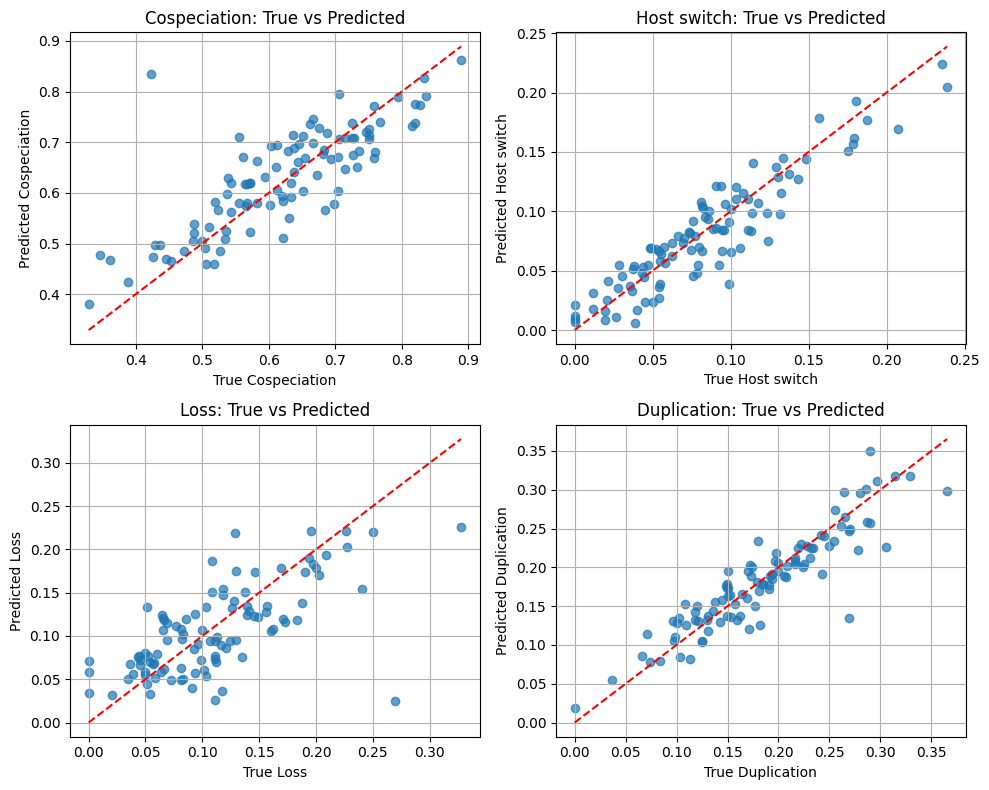

In [35]:
# plot true vs predicted
import matplotlib.pyplot as plt
import math

n = len(EVENT_NAMES)
cols = math.ceil(math.sqrt(n))
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten() if n > 1 else [axes]

for ax, event in zip(axes, EVENT_NAMES):
    true = df[f"true_{event}"]
    pred = df[f"pred_{event}"]
    ax.scatter(true, pred, alpha=0.7)
    ax.plot([true.min(), true.max()], [true.min(), true.max()], 'r--')
    ax.set_xlabel(f"True {disp(event)}")
    ax.set_ylabel(f"Predicted {disp(event)}")
    ax.set_title(f"{disp(event)}: True vs Predicted")
    ax.grid(True)

# hide unused axes
for ax in axes[n:]:
    ax.set_visible(False)

fig.tight_layout()
plt.savefig("test_data/fox_predictions.png", dpi=120, bbox_inches="tight")
plt.show()

## AmoCoala setup

AmoCoala (https://github.com/sinaimeri/AmoCoala) is run on the true host and symbiont trees of each test
dataset and compared with Fox and with the simulator truth. The helpers below convert a `.tgl` to AmoCoala's
NEXUS input, run it, parse its output and compare it with Fox.

AmoCoala can take hours on some datasets. Each dataset gets at most a fixed number of minutes: past that the
Java process is killed and the dataset is written to `skipped.json` in the output folder, so later runs skip it
(`retry_skipped=True` tries them again). Finished datasets are never rerun, so the cells can be stopped and
restarted.

In [36]:
# ── AmoCoala helpers: .tgl -> AmoCoala NEXUS, run with a time limit, parse, compare ──
import glob, json, time, signal, subprocess
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed
from scipy import stats
from sklearn.metrics import r2_score

TGL_DIR          = "test_data/Datasets"
AMOCOALA_JAR     = os.environ.get("AMOCOALA_JAR", "/Users/gabriele/AmoCoala-main/AmoCoala.jar")
RUN_AMOCOALA     = True    # False: only read results already on disk
AC_TIMEOUT_MIN   = 30      # per dataset; slower datasets are killed and skipped (None: no limit)
AC_RETRY_SKIPPED = False   # True: retry datasets that timed out before
AC_WORKERS       = max(1, (os.cpu_count() or 4) // 2)

_STRIP_BL  = re.compile(r":[0-9eE+\-.]*[0-9]")
_STRIP_INT = re.compile(r"\)[A-Za-z0-9_]+")

def _parse_newick_subtrees(nwk):
    """{node name: set of leaf names below it}."""
    nwk = _STRIP_BL.sub("", nwk.strip().rstrip(";"))
    subtree = {}
    def parse(s, pos):
        if s[pos] == "(":
            pos += 1; leaves = []
            while pos < len(s) and s[pos] != ")":
                child, pos = parse(s, pos)
                leaves.extend(child)
                if pos < len(s) and s[pos] == ",":
                    pos += 1
            pos += 1; start = pos
            while pos < len(s) and s[pos] not in ",)(":
                pos += 1
            name = s[start:pos].strip()
            if name:
                subtree[name] = set(leaves)
            return leaves, pos
        start = pos
        while pos < len(s) and s[pos] not in ",)":
            pos += 1
        name = s[start:pos].strip()
        if name:
            subtree[name] = {name}
        return [name], pos
    parse(nwk, 0)
    return subtree

def _collapse_unary(nwk):
    # AmoCoala's addVerticalSpread only handles binary internal nodes (Tree.java:1018):
    # unary internals crash it (NPE at line 1125), so collapse them.
    nwk = nwk.strip().rstrip(";"); pos = [0]
    def parse():
        if pos[0] < len(nwk) and nwk[pos[0]] == "(":
            pos[0] += 1; ch = [parse()]
            while pos[0] < len(nwk) and nwk[pos[0]] == ",":
                pos[0] += 1; ch.append(parse())
            pos[0] += 1; start = pos[0]
            while pos[0] < len(nwk) and nwk[pos[0]] not in ",()":
                pos[0] += 1
            return (nwk[start:pos[0]], ch)
        start = pos[0]
        while pos[0] < len(nwk) and nwk[pos[0]] not in ",()":
            pos[0] += 1
        return (nwk[start:pos[0]], None)
    def simplify(node):
        label, ch = node
        if ch is None: return node
        ch = [simplify(c) for c in ch]
        return ch[0] if len(ch) == 1 else (label, ch)
    def ser(node):
        label, ch = node
        return label if ch is None else "(" + ",".join(ser(c) for c in ch) + ")" + label
    return ser(simplify(parse()))

def _expand_dist(distribution, host_nwk):
    # A symbiont mapped to an internal host node is linked to every host leaf below it.
    st = _parse_newick_subtrees(host_nwk)
    leaves = {n for n, v in st.items() if v == {n}}
    out, seen = [], set()
    for p, h in distribution:
        for t in ([h] if h in leaves else sorted(st.get(h, []))):
            if (p, t) not in seen:
                out.append((p, t)); seen.add((p, t))
    return out

def write_amocoala_nexus(tgl_path, nex_path):
    d = parse_tgl(tgl_path)
    if d["host_tree"] is None or d["para_tree"] is None:
        return "could not parse trees"
    dist = _expand_dist(d["distribution"], d["host_tree"])
    host_nwk = _collapse_unary(_STRIP_INT.sub(")", _STRIP_BL.sub("", d["host_tree"])))
    para_nwk = _collapse_unary(_STRIP_INT.sub(")", _STRIP_BL.sub("", d["para_tree"])))
    host_leaves = {n for n, v in _parse_newick_subtrees(host_nwk).items() if v == {n}}
    para_leaves = {n for n, v in _parse_newick_subtrees(para_nwk).items() if v == {n}}
    dist = [(p, h) for p, h in dist if p in para_leaves and h in host_leaves]
    if len(dist) < 3:
        return f"too few valid leaf mappings: {len(dist)}"
    with open(nex_path, "w") as f:
        f.write("#NEXUS\n"
                f"BEGIN HOST;\n\tTREE HOST = {host_nwk};\nENDBLOCK;\n"
                f"BEGIN PARASITE;\n\tTREE PARASITE = {para_nwk};\nENDBLOCK;\n"
                "BEGIN DISTRIBUTION;\n\tRANGE\n\t\t" + ", ".join(f"{p} : {h}" for p, h in dist)
                + ";\nENDBLOCK;\n")
    return None

def _stem(tgl_path):
    return os.path.splitext(os.path.basename(tgl_path))[0]

def result_csv(out_dir, stem, n_rounds):
    return os.path.join(out_dir, stem, f"{stem}.nex.accep.round_{n_rounds}.csv")

def run_amocoala(tgl_path, out_dir, n_rounds, timeout_min, n_sim=1000, tol=None):
    """Returns (status, seconds, message); status is ok / timeout / fail.
    n_sim: vectors sampled in round 1 (-N); tol: one acceptance threshold per round (-t, default 0.1 each)."""
    tol = tol or [0.1] * n_rounds
    stem = _stem(tgl_path)
    os.makedirs(os.path.join(out_dir, stem), exist_ok=True)
    nex = os.path.join(out_dir, stem, f"{stem}.nex")
    err = write_amocoala_nexus(tgl_path, nex)
    if err:
        return "fail", 0.0, err
    t0 = time.time()
    # own process group, so a timeout kills Java and anything it started
    proc = subprocess.Popen(["java", "-jar", AMOCOALA_JAR, "-input", nex, "-N", str(n_sim), "-M", "100",
                             "-R", str(n_rounds), "-t", ",".join(map(str, tol))],
                            stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True, start_new_session=True)
    try:
        out, errtxt = proc.communicate(timeout=None if timeout_min is None else timeout_min * 60)
    except subprocess.TimeoutExpired:
        os.killpg(proc.pid, signal.SIGKILL)
        proc.communicate()
        return "timeout", time.time() - t0, f"over {timeout_min} min"
    if os.path.exists(result_csv(out_dir, stem, n_rounds)):
        return "ok", time.time() - t0, ""
    return "fail", time.time() - t0, (errtxt or out)[-300:]

def run_amocoala_batch(tgls, out_dir, n_rounds, timeout_min=AC_TIMEOUT_MIN,
                       retry_skipped=AC_RETRY_SKIPPED, workers=AC_WORKERS, n_sim=1000, tol=None):
    """Runs AmoCoala on every .tgl without a result yet; too-slow ones go to <out_dir>/skipped.json."""
    os.makedirs(out_dir, exist_ok=True)
    skip_file = os.path.join(out_dir, "skipped.json")
    skipped = json.load(open(skip_file)) if os.path.exists(skip_file) else {}
    done = [p for p in tgls if os.path.exists(result_csv(out_dir, _stem(p), n_rounds))]
    todo = [p for p in tgls if p not in done and (retry_skipped or os.path.basename(p) not in skipped)]
    print(f"{len(tgls)} datasets: {len(done)} done, {len(skipped)} skipped as too slow, "
          f"{len(todo) if RUN_AMOCOALA else 0} to run ({workers} at a time, "
          f"{'no time limit' if timeout_min is None else f'{timeout_min} min limit each'})")
    if RUN_AMOCOALA and todo:
        with ThreadPoolExecutor(max_workers=workers) as ex:
            futures = {ex.submit(run_amocoala, p, out_dir, n_rounds, timeout_min, n_sim, tol): p for p in todo}
            for fut in as_completed(futures):
                name = os.path.basename(futures[fut])
                status, secs, msg = fut.result()
                print(f"[{time.strftime('%H:%M:%S')}] {status:7s} {name} ({secs / 60:.1f} min) {msg}", flush=True)
                if status == "timeout":
                    skipped[name] = round(secs)
                elif status == "ok":
                    skipped.pop(name, None)
                json.dump(skipped, open(skip_file, "w"), indent=1)
    n_ok = sum(os.path.exists(result_csv(out_dir, _stem(p), n_rounds)) for p in tgls)
    print(f"AmoCoala results: {n_ok} / {len(tgls)}; skipped as too slow: {sorted(skipped)}")

def parse_ac_csv(path):
    # columns: cospeciation, duplication, host switch, loss (one row per accepted simulation)
    rows = [[float(x) for x in line.split("\t") if x.strip()] for line in open(path)]
    rows = [r for r in rows if len(r) >= 4]
    if not rows:
        return None
    cospec, dup, hsw, loss = np.array(rows)[:, :4].mean(0)
    total = (cospec + dup + hsw + loss) or 1.0
    return {"Speciation": cospec / total, "Duplication": dup / total, "HGT": hsw / total, "Loss": loss / total}

def amocoala_vs_fox(tgls, out_dir, n_rounds, fox_df=None):
    """Truth, AmoCoala and Fox side by side (file = .tgl name), on datasets AmoCoala finished.
    Fox predictions come from df, where .tgl and .pt are matched on their label values, or from
    fox_df (predictions made on the .tgl files themselves), matched on the file name."""
    key = lambda vals: tuple(round(float(v), 4) for v in vals)
    fox_by_label = {key(r[f"true_{e}"] for e in EVENT_NAMES): r for _, r in df.iterrows()} if fox_df is None else {}
    fox_by_file = {} if fox_df is None else {r["file"]: r for _, r in fox_df.iterrows()}
    rows = []
    for tgl in tgls:
        csv = result_csv(out_dir, _stem(tgl), n_rounds)
        if not os.path.exists(csv):
            continue
        ac = parse_ac_csv(csv)
        truth = parse_tgl(tgl)["event_freqs"]
        fox = (fox_by_file.get(os.path.basename(tgl)) if fox_df is not None
               else fox_by_label.get(key(truth.get(e, 0.0) for e in EVENT_NAMES)))
        if ac is None or fox is None:
            continue
        r = {"file": os.path.basename(tgl)}
        r.update({f"true_{e}": truth[e] for e in EVENT_NAMES})
        r.update({f"ac_{e}": ac[e] for e in EVENT_NAMES})
        r.update({f"pred_{e}": fox[f"pred_{e}"] for e in EVENT_NAMES})
        rows.append(r)
    out = pd.DataFrame(rows)
    print(f"Matched: {len(out)} datasets with both AmoCoala ({n_rounds} round(s)) and Fox")
    metrics = []
    for e in EVENT_NAMES:
        t = out[f"true_{e}"]
        for name, col in (("AmoCoala", "ac"), ("Fox", "pred")):
            p = out[f"{col}_{e}"]
            metrics.append({"Event": disp(e), "Method": name, "MAE": np.abs(p - t).mean(),
                            "RMSE": np.sqrt(((p - t) ** 2).mean()), "R²": r2_score(t, p),
                            "Pearson r": stats.pearsonr(t, p)[0], "Bias": (p - t).mean()})
    display(pd.DataFrame(metrics).set_index(["Event", "Method"]).round(4))
    return out

def plot_amocoala_vs_fox(d, png, title):
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    for col, e in enumerate(EVENT_NAMES):
        t, a, p = d[f"true_{e}"], d[f"ac_{e}"], d[f"pred_{e}"]
        lo, hi = min(t.min(), a.min(), p.min()), max(t.max(), a.max(), p.max())
        for row, (vals, name, color, mk) in enumerate(((a, "AmoCoala", "C1", "s"), (p, "Fox", "C0", "o"))):
            ax = axes[row, col]
            ax.scatter(t, vals, alpha=0.7, s=50, color=color, marker=mk)   # marker per method: readable in B&W
            ax.plot([lo, hi], [lo, hi], "r--", lw=1)
            ax.set_title(f"{disp(e)}\n{name} r={stats.pearsonr(t, vals)[0]:.3f}")
            ax.set_xlabel("Simulator truth"); ax.set_ylabel(name); ax.grid(True)
    plt.suptitle(title, y=1.01)
    plt.tight_layout()
    plt.savefig(png, dpi=120, bbox_inches="tight")
    plt.show()

all_tgls = sorted(glob.glob(os.path.join(TGL_DIR, "*.tgl")),
                  key=lambda p: int(re.sub(r"\D", "", os.path.basename(p)) or 0))
print(f"AmoCoala helpers ready; {len(all_tgls)} test datasets in {TGL_DIR}")

AmoCoala helpers ready; 100 test datasets in test_data/Datasets


## Independent test set: treeducken

The AsymmeTree test set above comes from the simulator Fox is trained on, so it favours Fox. Fox is
therefore compared with AmoCoala (1 and 3 rounds, error vs tree size) on 100 datasets from a different
generator, treeducken (Dismukes & Heath 2021; local fork `Gabbo240900/treeducken`, which
fixes the switch/spread event codes). Host and symbiont trees are simulated together and dated, so AliSim adds
the MSAs for Fox, and AmoCoala gets the same trees as topologies.

Data: `test_data/treeducken/Datasets/`, made with
```
Rscript generate_data/treeducken_testset.R out=test_data/treeducken/Datasets n=100 seed=2026
python generate_data/alisim.py test_data/treeducken/Datasets --iqtree bin/bin_macos/iqtree_2.2.0 -l 250 -g yes
```
Rates are drawn from the same ranges as Fox's training data (`generate_trees.py`): cospeciation 0.5-1.2 (the
AsymmeTree host birth rate, since there every host speciation also splits the symbiont), duplication 0.2-0.4,
host switch 0.05-0.3, loss 0.2-0.4; no host speciation without the symbiont and no host extinction, because
AsymmeTree's host trees keep no extinct hosts. `hs_mode = "switch"`. Extinct symbiont lineages are pruned
(15-50 extant hosts, 10-80 extant symbionts). Labels follow the AsymmeTree convention, on the full symbiont tree: a branching node counts as its
event (cospeciation, duplication = symbiont speciation without the host, host switch = switch or spread) only
if both of its sides survive to the present; every extinct symbiont leaf is one loss. So total events = all
symbiont leaves - 1 and total - losses = extant symbiont leaves - 1, as in the AsymmeTree data.

Fox reads the `.tgl` files directly, and Fox and AmoCoala are matched by file name.

In [37]:
TD_TGL_DIR = "test_data/treeducken/Datasets"

import glob
td_tgls = sorted(glob.glob(os.path.join(TD_TGL_DIR, "*.tgl")),
                 key=lambda p: int(re.sub(r"\D", "", os.path.basename(p)) or 0))

print(f"Found {len(td_tgls)} files")
df_td = predict(td_tgls)
df_td['speciation_diff'] = df_td['pred_Speciation'] -  df_td['true_Speciation']
df_td['HGT_diff'] = df_td['pred_HGT'] - df_td['true_HGT']
df_td['Loss_diff'] = df_td['pred_Loss'] - df_td['true_Loss']
df_td['Duplication_diff'] = df_td['pred_Duplication'] - df_td['true_Duplication']
print(df_td)

Found 100 files
              file  pred_Speciation  pred_HGT  pred_Loss  pred_Duplication  \
0     Dataset1.tgl         0.576947  0.029616   0.181339          0.212099   
1     Dataset2.tgl         0.296918  0.142939   0.325382          0.234760   
2     Dataset3.tgl         0.388320  0.102107   0.264662          0.244912   
3     Dataset4.tgl         0.409559  0.078001   0.259160          0.253281   
4     Dataset5.tgl         0.324601  0.164517   0.291894          0.218988   
..             ...              ...       ...        ...               ...   
95   Dataset96.tgl         0.792958  0.045024   0.095938          0.066080   
96   Dataset97.tgl         0.489495  0.098179   0.253882          0.158445   
97   Dataset98.tgl         0.661572  0.104997   0.178517          0.054913   
98   Dataset99.tgl         0.387843  0.165353   0.278271          0.168533   
99  Dataset100.tgl         0.289998  0.081416   0.430396          0.198190   

    true_Speciation  true_HGT  true_Loss  true_

In [38]:
from scipy import stats
from sklearn.metrics import r2_score
import numpy as np

td_rows_metrics = []
for event in EVENT_NAMES:
    true = df_td[f"true_{event}"].values
    pred = df_td[f"pred_{event}"].values
    diff = pred - true
    mae  = np.abs(diff).mean()
    rmse = np.sqrt((diff**2).mean())
    r2   = r2_score(true, pred)
    bias = diff.mean()
    td_rows_metrics.append({
        "Event": event,
        "MAE": mae,
        'MRE': mae / np.mean(true) if np.mean(true) > 0 else 1e-6,
        "RMSE": rmse,
        "R²": r2,
        "Bias": bias,
    })

td_metrics_df = pd.DataFrame(td_rows_metrics).set_index("Event")
print(td_metrics_df.round(4))

                MAE     MRE    RMSE      R²    Bias
Event                                              
Speciation   0.0818  0.1520  0.0993  0.2464 -0.0566
HGT          0.0352  0.4155  0.0431  0.4098  0.0145
Loss         0.0805  0.4038  0.1006 -0.1645  0.0236
Duplication  0.0424  0.2382  0.0531  0.5456  0.0186


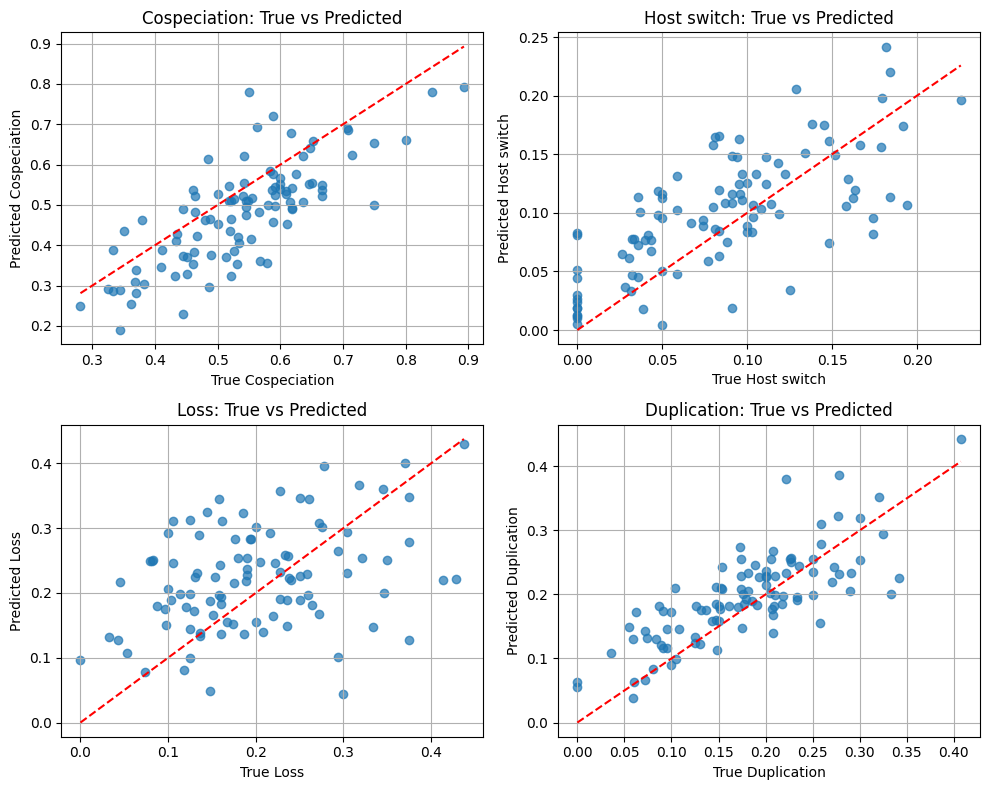

In [39]:
# plot true vs predicted (treeducken)
import matplotlib.pyplot as plt
import math

n = len(EVENT_NAMES)
cols = math.ceil(math.sqrt(n))
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten() if n > 1 else [axes]

for ax, event in zip(axes, EVENT_NAMES):
    true = df_td[f"true_{event}"]
    pred = df_td[f"pred_{event}"]
    ax.scatter(true, pred, alpha=0.7)
    ax.plot([true.min(), true.max()], [true.min(), true.max()], 'r--')
    ax.set_xlabel(f"True {disp(event)}")
    ax.set_ylabel(f"Predicted {disp(event)}")
    ax.set_title(f"{disp(event)}: True vs Predicted")
    ax.grid(True)

# hide unused axes
for ax in axes[n:]:
    ax.set_visible(False)

fig.tight_layout()
plt.savefig("test_data/treeducken/fox_predictions.png", dpi=120, bbox_inches="tight")
plt.show()

### AmoCoala comparison on treeducken data

1 AmoCoala round on every dataset (`-N 1000 -M 100 -t 0.1`), at most 90 minutes per dataset, smallest
datasets first. Results go to
`test_data/treeducken/amocoala_data/`; finished datasets are never rerun, so the cells can be stopped and
restarted.

In [40]:
# ── AmoCoala, 1 round, all treeducken datasets (resumable) ──
AC_DIR_TD_1 = "test_data/treeducken/amocoala_data"
# 90 min limit each, smallest (symbiont leaves) first
td_n_sym_leaves = lambda p: int(re.search(r"Symbiont_num_leaves: (\d+)", open(p).read()).group(1))
run_amocoala_batch(sorted(td_tgls, key=td_n_sym_leaves), AC_DIR_TD_1, n_rounds=1,
                   timeout_min=90, retry_skipped=False)

100 datasets: 100 done, 0 skipped as too slow, 0 to run (7 at a time, 90 min limit each)
AmoCoala results: 100 / 100; skipped as too slow: []


In [41]:
df_cmp_td_1 = amocoala_vs_fox(td_tgls, AC_DIR_TD_1, n_rounds=1, fox_df=df_td)

Matched: 100 datasets with both AmoCoala (1 round(s)) and Fox


MAE    RMSE      R²  Pearson r    Bias
Event        Method                                             
Cospeciation AmoCoala  0.1122  0.1442 -0.5911     0.0062 -0.0764
             Fox       0.0818  0.0993  0.2464     0.7749 -0.0566
Host switch  AmoCoala  0.1504  0.1611 -7.2376     0.1328  0.1504
             Fox       0.0352  0.0431  0.4098     0.7158  0.0145
Loss         AmoCoala  0.0724  0.0880  0.1081     0.3705  0.0153
             Fox       0.0805  0.1006 -0.1645     0.3657  0.0236
Duplication  AmoCoala  0.0959  0.1158 -1.1641     0.4394 -0.0892
             Fox       0.0424  0.0531  0.5456     0.7831  0.0186

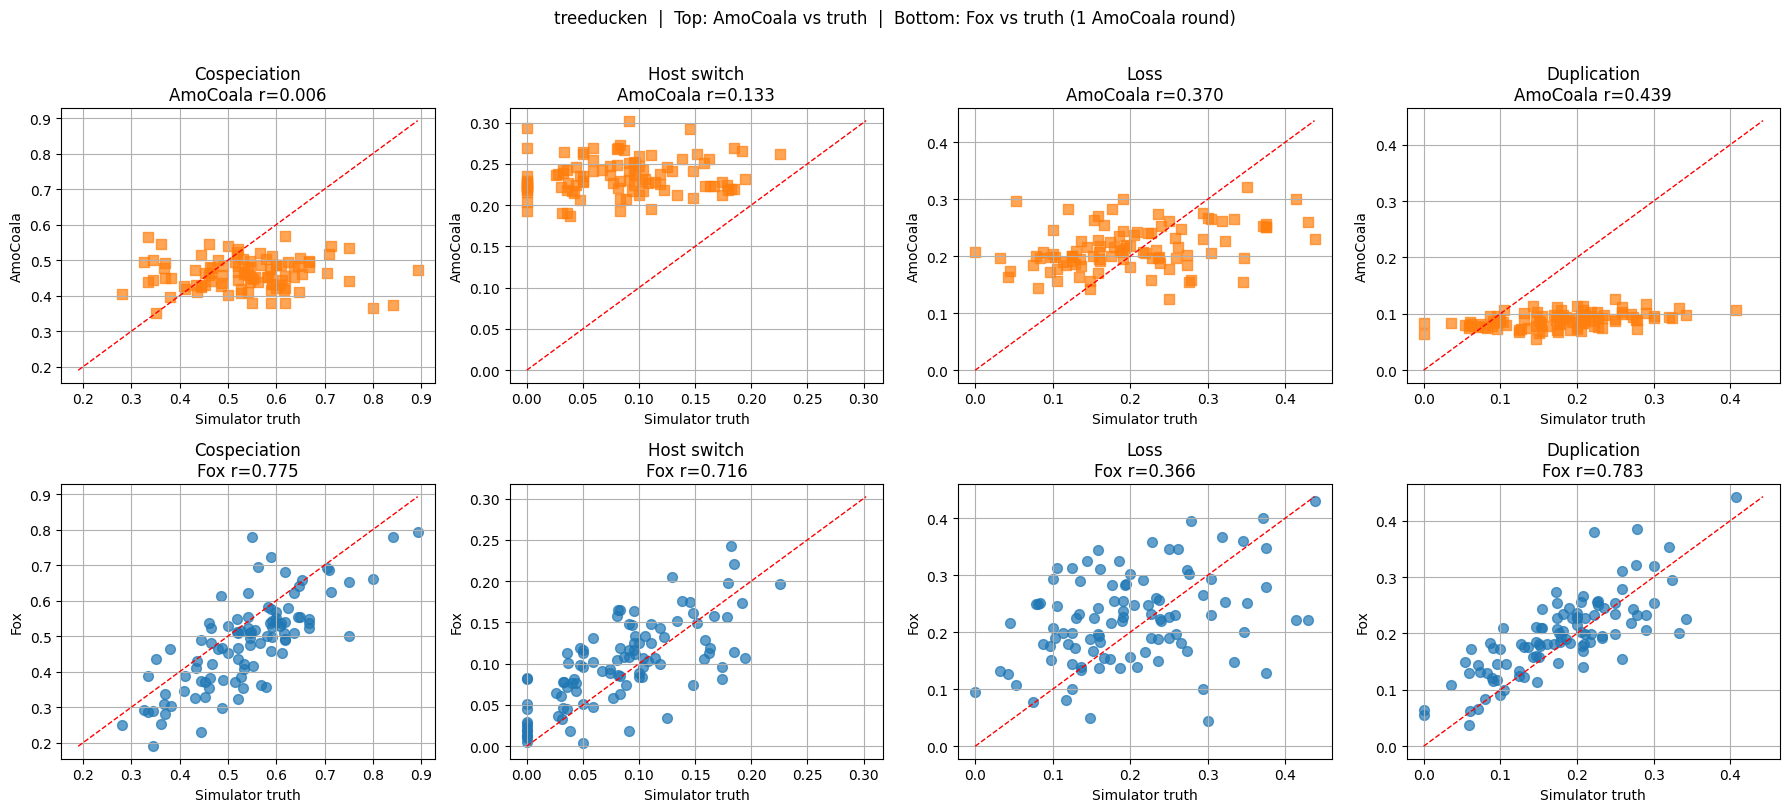

In [42]:
plot_amocoala_vs_fox(df_cmp_td_1, "test_data/treeducken/amocoala_vs_fox.png",
                     "treeducken  |  Top: AmoCoala vs truth  |  Bottom: Fox vs truth (1 AmoCoala round)")

### Performance vs. tree size (treeducken)

Does accuracy degrade on larger trees? Scatter, binned and per-event MAE for Fox and AmoCoala against host and
parasite leaf count. Parasite leaves include extinct ones, as in the AsymmeTree data.

Datasets with leaf info: 100


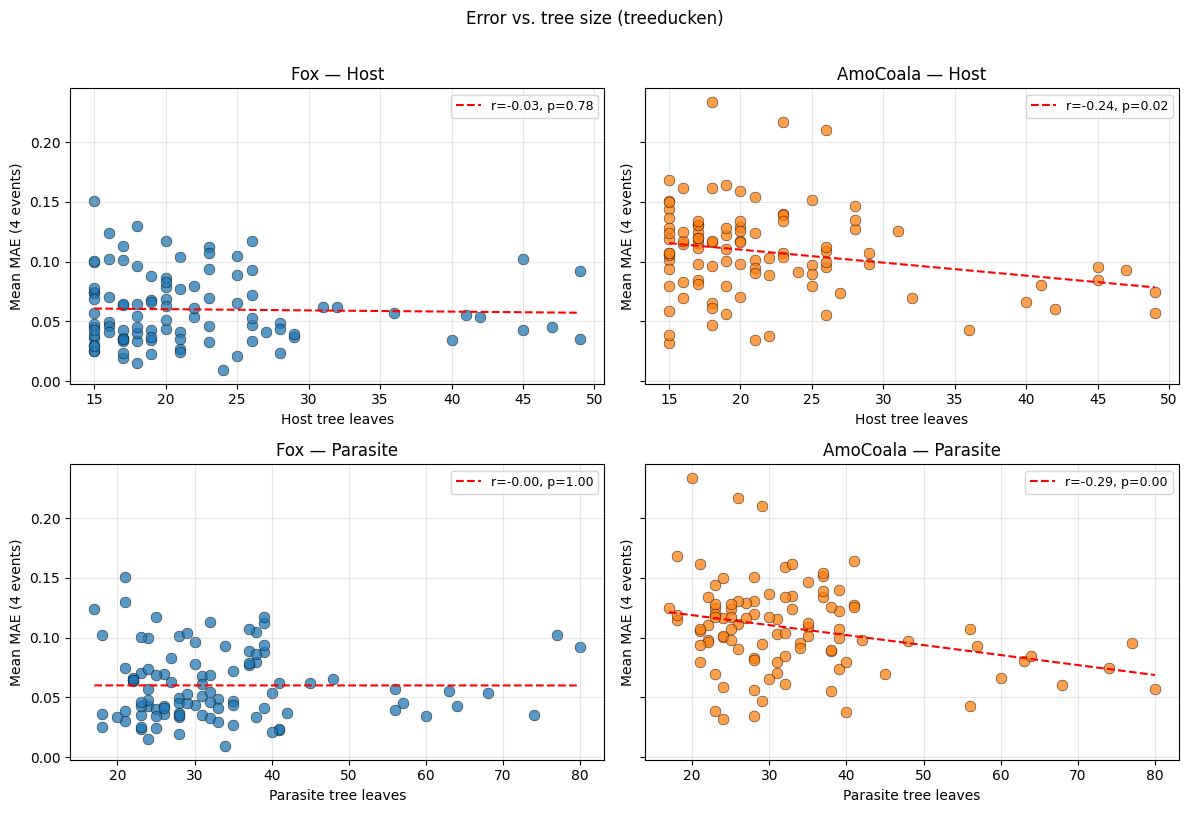


Binned MAE — Host leaves:
                  N  Fox MAE  AmoCoala MAE
Bin                                       
Small\n(≤17)     34   0.0595        0.1107
Medium\n(18–22)  32   0.0603        0.1074
Large\n(≥23)     34   0.0601        0.1050

Binned MAE — Parasite leaves:
                  N  Fox MAE  AmoCoala MAE
Bin                                       
Small\n(≤26)     36   0.0599        0.1159
Medium\n(27–35)  33   0.0553        0.1079
Large\n(≥37)     31   0.0650        0.0981


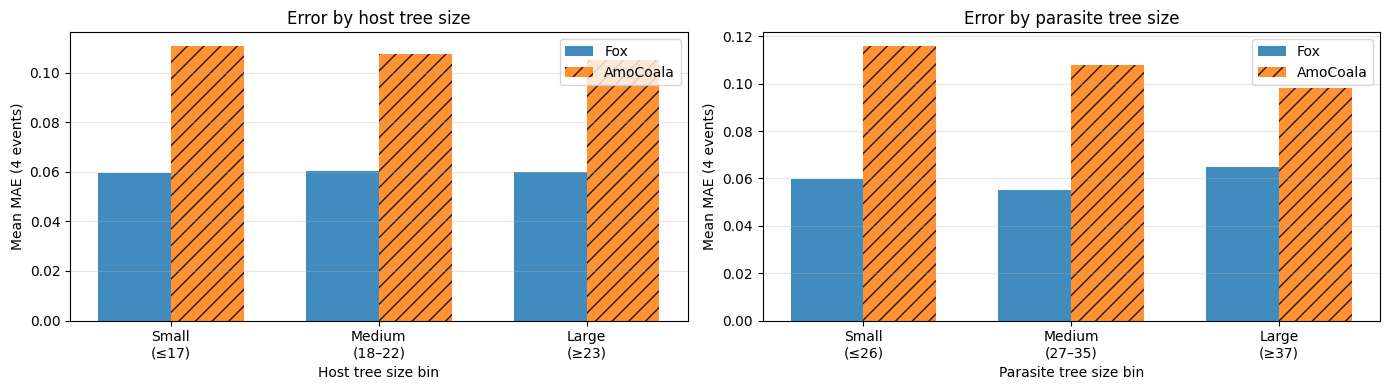

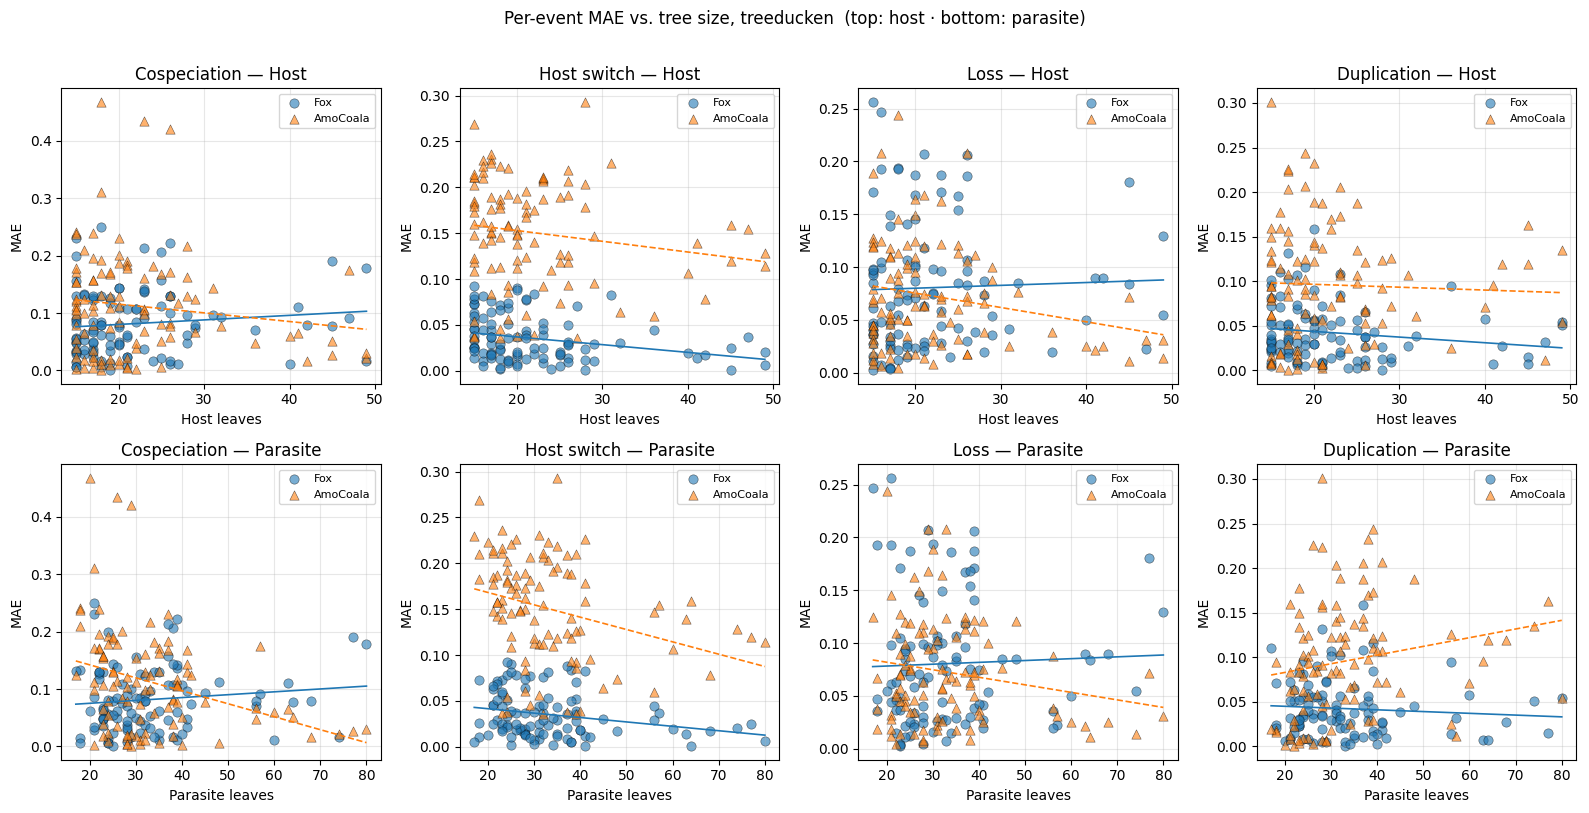

In [43]:
# ── Performance vs. tree size (host & parasite), treeducken ───────────────────
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats

TD_TGL_DIR = "test_data/treeducken/Datasets"

leaf_rows_td = []
for tgl in sorted(__import__('glob').glob(f"{TD_TGL_DIR}/*.tgl")):
    txt = open(tgl).read()
    h = re.search(r"Host_num_leaves: (\d+)", txt)
    s = re.search(r"Symbiont_num_leaves: (\d+)", txt)
    if h and s:
        leaf_rows_td.append({
            "file": __import__('os').path.basename(tgl),
            "host_leaves": int(h.group(1)),
            "sym_leaves":  int(s.group(1)),
        })

df_leaves_td = pd.DataFrame(leaf_rows_td)
df_sz_td = df_cmp_td_1.merge(df_leaves_td, on="file", how="inner")
print(f"Datasets with leaf info: {len(df_sz_td)}")

for model_name, prefix in [("Fox", "pred"), ("AmoCoala", "ac")]:
    df_sz_td[f"mae_{model_name}"] = np.mean(
        [np.abs(df_sz_td[f"{prefix}_{e}"] - df_sz_td[f"true_{e}"]) for e in EVENT_NAMES], axis=0
    )

TREE_DIMS = [("host_leaves", "Host"), ("sym_leaves", "Parasite")]

# ── Figure 1: scatter MAE vs tree size (2 rows = host/para, 2 cols = model) ──
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
for row, (col_name, dim_label) in enumerate(TREE_DIMS):
    for ax, (model_name, color) in zip(axes[row], [("Fox", "C0"), ("AmoCoala", "C1")]):
        x = df_sz_td[col_name]
        y = df_sz_td[f"mae_{model_name}"]
        ax.scatter(x, y, alpha=0.75, s=60, color=color, edgecolors="k", linewidths=0.4)
        m, b, r, p, _ = stats.linregress(x, y)
        xl = np.array([x.min(), x.max()])
        ax.plot(xl, m * xl + b, "r--", lw=1.5, label=f"r={r:.2f}, p={p:.2f}")
        ax.set_xlabel(f"{dim_label} tree leaves")
        ax.set_ylabel("Mean MAE (4 events)")
        ax.set_title(f"{model_name} — {dim_label}")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
plt.suptitle("Error vs. tree size (treeducken)", y=1.01)
plt.tight_layout()
plt.savefig("test_data/treeducken/error_vs_treesize_scatter.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Figure 2: binned MAE bar chart (side-by-side host / parasite) ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (col_name, dim_label) in zip(axes, TREE_DIMS):
    bins_cat = pd.qcut(df_sz_td[col_name], q=3, labels=["Small", "Medium", "Large"])
    bin_summary = []
    for b in bins_cat.cat.categories:
        sub = df_sz_td[bins_cat == b]
        lo, hi = sub[col_name].min(), sub[col_name].max()
        label = f"{b}\n(≤{hi})" if b == "Small" else (f"{b}\n(≥{lo})" if b == "Large" else f"{b}\n({lo}–{hi})")
        bin_summary.append({"Bin": label, "N": len(sub),
                             "Fox MAE": sub["mae_Fox"].mean(),
                             "AmoCoala MAE": sub["mae_AmoCoala"].mean()})
    df_bin_td = pd.DataFrame(bin_summary).set_index("Bin")
    print(f"\nBinned MAE — {dim_label} leaves:")
    print(df_bin_td.round(4))
    x_pos = np.arange(len(df_bin_td)); w = 0.35
    ax.bar(x_pos - w/2, df_bin_td["Fox MAE"],  w, label="Fox",  color="C0", alpha=0.85)
    ax.bar(x_pos + w/2, df_bin_td["AmoCoala MAE"], w, label="AmoCoala", color="C1", alpha=0.85,
           hatch="//", edgecolor="black", linewidth=0)  # stripes: readable in B&W
    ax.set_xticks(x_pos); ax.set_xticklabels(df_bin_td.index)
    ax.set_ylabel("Mean MAE (4 events)")
    ax.set_xlabel(f"{dim_label} tree size bin")
    ax.set_title(f"Error by {dim_label.lower()} tree size")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("test_data/treeducken/error_vs_treesize_binned.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Figure 3: per-event MAE vs tree size (2 rows = host/para, 4 cols = event) ─
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for row, (col_name, dim_label) in enumerate(TREE_DIMS):
    for ax, event in zip(axes[row], EVENT_NAMES):
        x = df_sz_td[col_name]
        # marker + line style per model: readable in B&W
        for model_key, color, marker, ls, lbl in [("pred", "C0", "o", "-",  "Fox"),
                                                  ("ac",   "C1", "^", "--", "AmoCoala")]:
            y = np.abs(df_sz_td[f"{model_key}_{event}"] - df_sz_td[f"true_{event}"])
            ax.scatter(x, y, alpha=0.6, s=45, color=color, marker=marker,
                       edgecolors="k", linewidths=0.4, label=lbl)
            m, b, r, p, _ = stats.linregress(x, y)
            xl = np.array([x.min(), x.max()])
            ax.plot(xl, m * xl + b, ls, color=color, lw=1.2)
        ax.set_title(f"{disp(event)} — {dim_label}")
        ax.set_xlabel(f"{dim_label} leaves")
        ax.set_ylabel("MAE")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
plt.suptitle("Per-event MAE vs. tree size, treeducken  (top: host · bottom: parasite)", y=1.01)
plt.tight_layout()
plt.savefig("test_data/treeducken/error_vs_treesize_per_event.png", dpi=120, bbox_inches="tight")
plt.show()

### AmoCoala with more rounds (treeducken)

3 AmoCoala rounds on the
20 smallest treeducken datasets (by number of symbiont leaves), no time limit. AmoCoala keeps a share of the vectors in each round
(`-t`); with 1000 vectors and 0.1 in every round only 10 would be left after round 3, too few for a stable
estimate, so this run samples 2000 vectors and keeps 10%, 25%, 25% (`-N 2000 -t 0.1,0.25,0.25`), leaving 50.
AmoCoala is much faster here
than on the AsymmeTree set because the treeducken trees are smaller (median 24 extant symbionts vs 66), so
20 datasets are affordable instead of the 5 used in the AsymmeTree extra; they all have 18 or fewer extant symbionts. Results go to
`test_data/treeducken/amocoala_small_N2000/`.

In [44]:
# ── AmoCoala, 3 rounds, 20 treeducken datasets (resumable) ──
AC_DIR_TD_3 = "test_data/treeducken/amocoala_small_N2000"
AC_N_3, AC_TOL_3 = 2000, [0.1, 0.25, 0.25]   # 2000 x 0.1 x 0.25 x 0.25 = 50 vectors left after round 3
N_SMALL  = 20
td_n_sym = lambda p: int(re.search(r"Symbiont_num_leaves: (\d+)", open(p).read()).group(1))
td_small_tgls = sorted(td_tgls, key=td_n_sym)[:N_SMALL]   # the 20 smallest treeducken datasets (symbiont leaves)
print("Datasets:", [os.path.basename(p) for p in td_small_tgls])
run_amocoala_batch(td_small_tgls, AC_DIR_TD_3, n_rounds=3, timeout_min=None, retry_skipped=True,   # no time limit
                   n_sim=AC_N_3, tol=AC_TOL_3)

Datasets: ['Dataset94.tgl', 'Dataset6.tgl', 'Dataset20.tgl', 'Dataset23.tgl', 'Dataset39.tgl', 'Dataset26.tgl', 'Dataset56.tgl', 'Dataset60.tgl', 'Dataset65.tgl', 'Dataset73.tgl', 'Dataset8.tgl', 'Dataset25.tgl', 'Dataset54.tgl', 'Dataset97.tgl', 'Dataset19.tgl', 'Dataset24.tgl', 'Dataset35.tgl', 'Dataset51.tgl', 'Dataset89.tgl', 'Dataset90.tgl']
20 datasets: 20 done, 0 skipped as too slow, 0 to run (7 at a time, no time limit)
AmoCoala results: 20 / 20; skipped as too slow: []


In [45]:
df_cmp_td_3 = amocoala_vs_fox(td_small_tgls, AC_DIR_TD_3, n_rounds=3, fox_df=df_td)

Matched: 20 datasets with both AmoCoala (3 round(s)) and Fox


MAE    RMSE       R²  Pearson r    Bias
Event        Method                                              
Cospeciation AmoCoala  0.1351  0.1730  -2.0260     0.1914 -0.0850
             Fox       0.0927  0.1133  -0.2966     0.4277 -0.0318
Host switch  AmoCoala  0.1999  0.2118 -22.7909    -0.0073  0.1923
             Fox       0.0423  0.0480  -0.2211     0.7909  0.0293
Loss         AmoCoala  0.0703  0.0869   0.0193     0.4710 -0.0189
             Fox       0.0857  0.1167  -0.7709    -0.0900 -0.0286
Duplication  AmoCoala  0.0929  0.1132  -2.1570    -0.0781 -0.0884
             Fox       0.0397  0.0485   0.4215     0.8167  0.0310

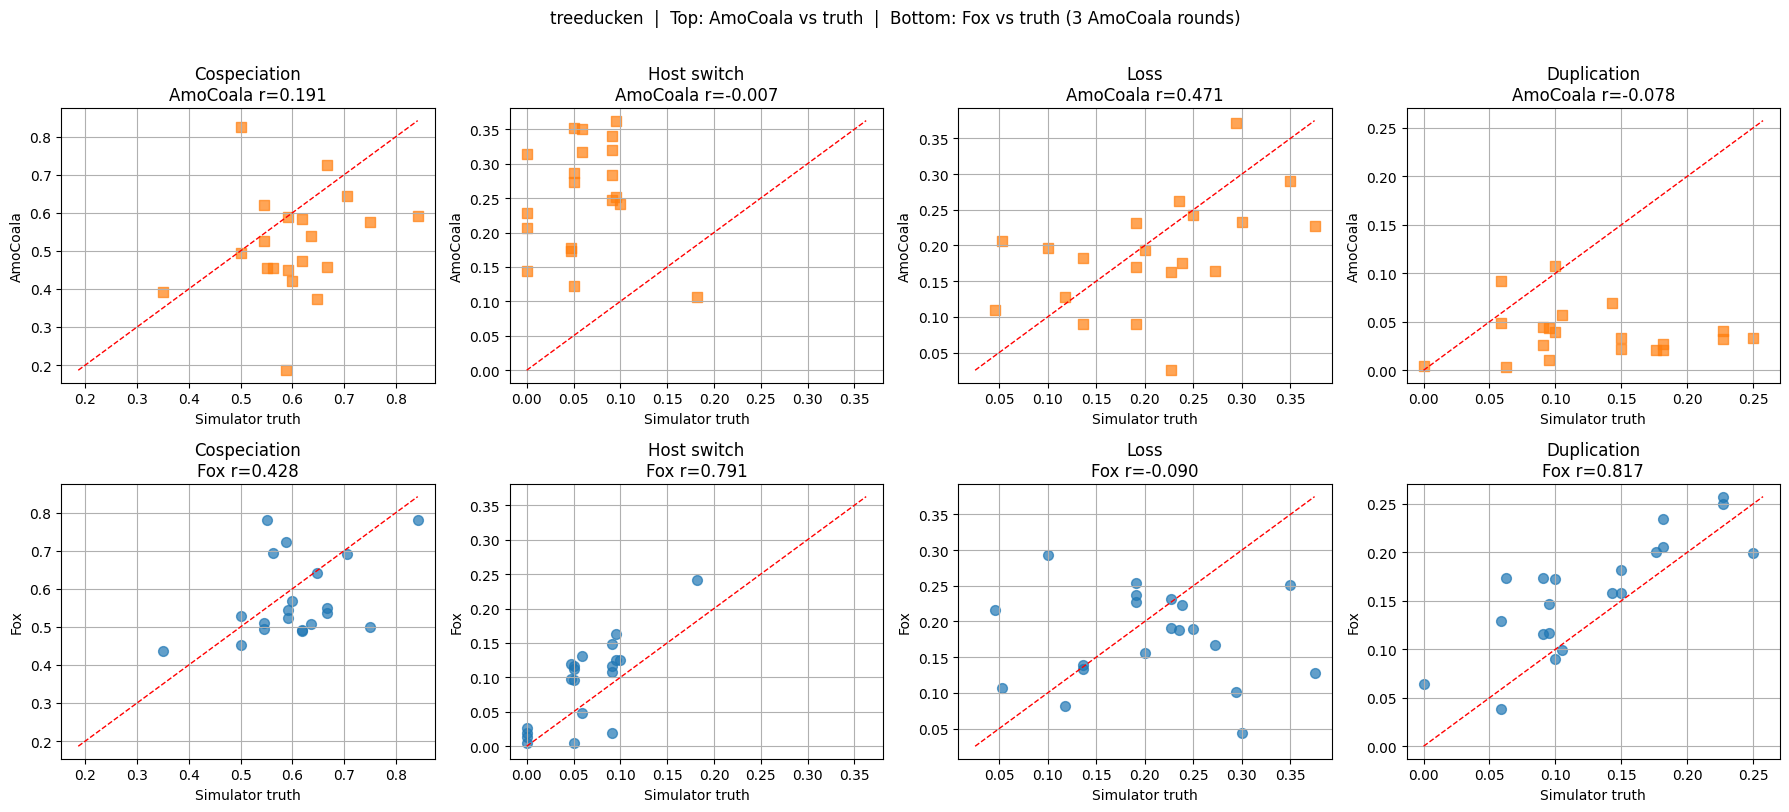

In [46]:
plot_amocoala_vs_fox(df_cmp_td_3, "test_data/treeducken/amocoala_vs_fox_3rounds.png",
                     "treeducken  |  Top: AmoCoala vs truth  |  Bottom: Fox vs truth (3 AmoCoala rounds)")

## Real data: cockroaches and *Blattabacterium*

Arab et al. (2020, *Biol. Lett.* 16: 20190702; data Dryad doi:10.5061/dryad.v6wwpzgqw, CC0): 55 cockroach /
*Blattabacterium* pairs across all cockroach families. Amino-acid alignments of 13 mitochondrial proteins (host)
and 104 symbiont genes. The symbiont is passed from mother to offspring and the two trees are almost fully
congruent (ParaFit p = 0.001), so the expected answer is **mostly cospeciation**.

Unlike *Heliconius* (Extra section at the end), these alignments are divergent enough to be close to the training range (mean protein
distance about 0.5 host / 0.3 symbiont, vs 1.2 in training; about 60% variable columns). Three pairs with
ambiguous labels are dropped (52 left), and 50 are used because Fox takes at most 50 hosts.

The full alignments go into one `.tgl` (50 pairs, one-to-one links); as for the synthetic data, it is
pre-encoded with `training/pre_encoder.py` (`--keep-all-leaves`: real data has no dated trees to drop lost
leaves from), and Fox reads the first 250 amino acids of each alignment (3.3% gaps in the host, 7.6% in the
symbiont):
```
python test_data/real_data/blattabacterium/make_tgl.py
python training/pre_encoder.py --src test_data/real_data/blattabacterium/Datasets \
    --dst test_data/real_data/blattabacterium/fox_data --keep-all-leaves
```

In [47]:
# -- Build the .tgl, pre-encode it, run Fox --
import subprocess
BLAT = "test_data/real_data/blattabacterium"
if not glob.glob(f"{BLAT}/Datasets/*.tgl"):
    subprocess.run([sys.executable, f"{BLAT}/make_tgl.py"], check=True)
if not glob.glob(f"{BLAT}/fox_data/*.pt"):
    subprocess.run([sys.executable, "training/pre_encoder.py", "--src", f"{BLAT}/Datasets",
                    "--dst", f"{BLAT}/fox_data", "--keep-all-leaves"], check=True)

df_blat = predict(sorted(glob.glob(f"{BLAT}/fox_data/*.pt")))
blat_pred = {e: df_blat[f"pred_{e}"].iloc[0] for e in EVENT_NAMES}
print("Fox on the cockroach / Blattabacterium data (50 pairs, first 250 amino acids):")
for e in EVENT_NAMES:
    print(f"  {disp(e):13s} {blat_pred[e]:.3f}")

Fox on the cockroach / Blattabacterium data (50 pairs, first 250 amino acids):
  Cospeciation  0.610
  Host switch   0.170
  Loss          0.142
  Duplication   0.078


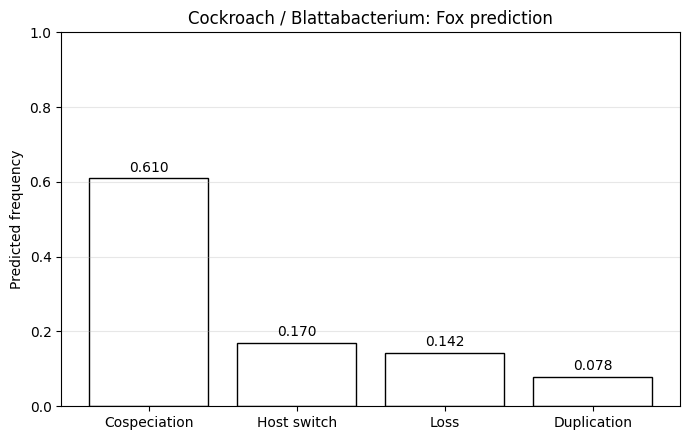

In [48]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar([disp(e) for e in EVENT_NAMES], [blat_pred[e] for e in EVENT_NAMES],
              color="white", edgecolor="black")
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01, f"{b.get_height():.3f}", ha="center", va="bottom")
ax.set_ylabel("Predicted frequency"); ax.set_ylim(0, 1); ax.grid(True, axis="y", alpha=0.3)
ax.set_title("Cockroach / Blattabacterium: Fox prediction")
fig.tight_layout()
plt.savefig(f"{BLAT}/fox_predictions_blattabacterium.png", dpi=120, bbox_inches="tight")
plt.show()

## Robustness to alignment length

Fox reads a fixed window of `MAX_SEQ_LEN = 250` columns (shorter alignments are
padded; longer ones are truncated). Here we probe how accuracy depends on the
number of informative columns: for each held-out test dataset we truncate every
sequence to `k` columns (k = 50, 100, 150, 200, 250), pad back to the 250 window,
re-run Fox, and score against the ground truth. This isolates the effect of
alignment length (same sites, fewer of them). Testing lengths **beyond** 250 would
require raising `MAX_SEQ_LEN` and retraining, since the window is fixed.

In [49]:
# -- Length sweep: truncate test MSAs to k columns, re-score Fox --
import glob, numpy as np, pandas as pd

EVENT_NAMES = ["Speciation", "HGT", "Loss", "Duplication"]
LENS  = [50, 100, 150, 200, 250]
files = sorted(glob.glob(f"{DATA_DIR}/*.pt"))

def _pred_at_len(hm, pm, maps, k):
    ht = torch.stack([encode_sequence(s[:k]) for s in hm.values()])   # first k cols, pad to 250
    pt = torch.stack([encode_sequence(s[:k]) for s in pm.values()])
    with torch.no_grad():
        o = model(ht.unsqueeze(0).to(device), pt.unsqueeze(0).to(device), [maps],
                  host_dist=jukes_cantor_dist(ht).unsqueeze(0).to(device),
                  para_dist=jukes_cantor_dist(pt).unsqueeze(0).to(device))
    return o.squeeze(0).cpu().tolist()

sweep = {L: {"pred": [], "true": []} for L in LENS}
for i, f in enumerate(files):
    s = load_as_strings(f)
    hm, pm = s["host_msas"], s["parasite_msas"]
    hi = {n: j for j, n in enumerate(hm)}; pi = {n: j for j, n in enumerate(pm)}
    raw = s["mappings"]
    maps = ([(hi[h], pi[p]) for p, h in raw if p in pi and h in hi]
            if raw and isinstance(raw[0][0], str) else raw)
    true = [s["event_frequencies"][e] for e in EVENT_NAMES]
    for L in LENS:
        sweep[L]["pred"].append(_pred_at_len(hm, pm, maps, L))
        sweep[L]["true"].append(true)
    if (i + 1) % 20 == 0:
        print(f"  {i+1}/{len(files)} done")

rows = []
for L in LENS:
    P = np.array(sweep[L]["pred"]); T = np.array(sweep[L]["true"])
    mae = np.abs(P - T).mean(0)
    r2  = 1 - ((T - P) ** 2).sum(0) / ((T - T.mean(0)) ** 2).sum(0)
    for j, e in enumerate(EVENT_NAMES):
        rows.append({"length": L, "event": e, "MAE": mae[j], "R2": r2[j]})
sweep_df = pd.DataFrame(rows)

print("\nR^2 by alignment length:")
print(sweep_df.pivot(index="length", columns="event", values="R2").round(3))
print("\nMAE by alignment length:")
print(sweep_df.pivot(index="length", columns="event", values="MAE").round(4))

  20/100 done
  40/100 done
  60/100 done
  80/100 done
  100/100 done

R^2 by alignment length:
event   Duplication    HGT   Loss  Speciation
length                                       
50            0.728 -1.114 -1.211      -0.546
100           0.816  0.618  0.255       0.525
150           0.818  0.788  0.433       0.645
200           0.829  0.835  0.439       0.651
250           0.827  0.847  0.449       0.648

MAE by alignment length:
event   Duplication     HGT    Loss  Speciation
length                                         
50           0.0276  0.0650  0.0769      0.1280
100          0.0222  0.0255  0.0419      0.0639
150          0.0214  0.0189  0.0341      0.0517
200          0.0210  0.0167  0.0338      0.0515
250          0.0207  0.0160  0.0339      0.0503


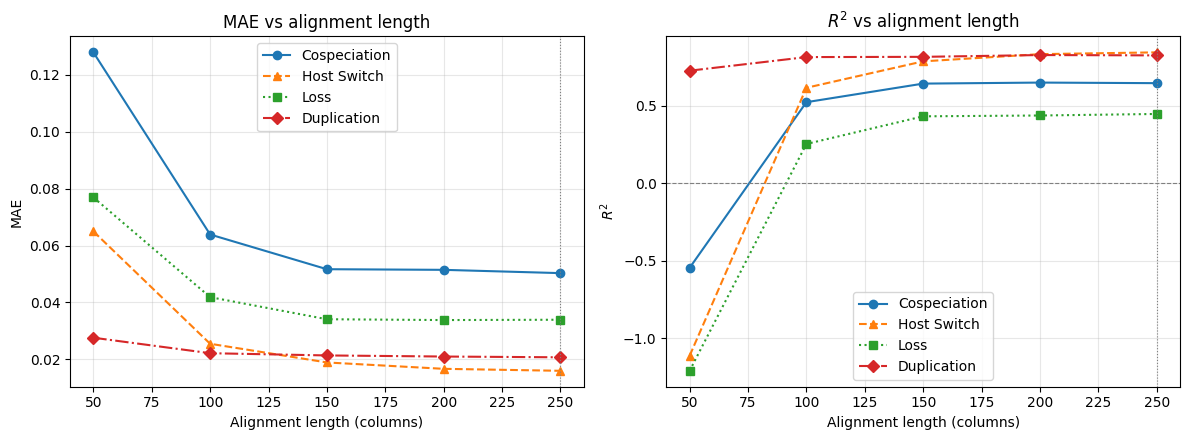

Saved: test_data/error_vs_seqlen.png


In [50]:
# -- Plot MAE and R^2 vs alignment length --
import matplotlib.pyplot as plt

DISPLAY = {"Speciation": "Cospeciation", "HGT": "Host Switch",
           "Loss": "Loss", "Duplication": "Duplication"}

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
# marker + line style per event: readable in B&W
for e, mk, ls in zip(EVENT_NAMES, ["o", "^", "s", "D"], ["-", "--", ":", "-."]):
    sub = sweep_df[sweep_df.event == e].sort_values("length")
    ax[0].plot(sub.length, sub.MAE, marker=mk, ls=ls, label=DISPLAY[e])
    ax[1].plot(sub.length, sub.R2,  marker=mk, ls=ls, label=DISPLAY[e])
ax[0].set(xlabel="Alignment length (columns)", ylabel="MAE", title="MAE vs alignment length")
ax[1].set(xlabel="Alignment length (columns)", ylabel="$R^2$", title="$R^2$ vs alignment length")
ax[1].axhline(0, color="gray", lw=0.8, ls="--")
for a in ax:
    a.axvline(250, color="gray", lw=0.8, ls=":")   # trained window
    a.grid(alpha=0.3); a.legend()
plt.tight_layout()
plt.savefig("test_data/error_vs_seqlen.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: test_data/error_vs_seqlen.png")

## Permutation invariance of the MSA row order

A model that estimates cophylogenetic event frequencies should not care about the
*order* in which sequences are listed in the host and parasite MSAs - the same pair of
trees is being described either way. (A bug of exactly this kind was found in evoPF's
outer-product mean.)

The shuffling follows Luc's `shuffle_seqs` datasets in `core.py`
(`UnambiguousMergeOrderDataset` / `MultisizeUnambiguousMergeOrderDataset`): a seeded
`torch.Generator`, `perm = torch.randperm(len(ids))`, MSA rows permuted by `perm` and
the **id list permuted the same way**, with everything downstream rebuilt from the
reordered ids. Adapted here to Fox's paired input: host and parasite MSAs get
independent permutations, the stored distance matrices are permuted consistently
(`D[perm][:, perm]`), and the host/parasite associations are rebuilt **from the leaf
names**, not by index arithmetic - so a wrong permutation shows up as scrambled
associations instead of silently agreeing.

Run over **all** datasets in `DATA_DIR`. Predictions should be identical up to float32
round-off (~1e-7).

In [51]:
# -- Shuffled dataset (mirrors Luc's `shuffle_seqs` datasets in core.py) --
import glob
import numpy as np
import pandas as pd
from torch.utils.data import Dataset

class ShuffledCophyloDataset(Dataset):
    """Fox .pt datasets, optionally with host/parasite leaf order shuffled.

    Same shuffling contract as core.py's UnambiguousMergeOrderDataset:
    seeded torch.Generator -> randperm over ids -> permute rows AND ids, then
    rebuild everything that references the leaves from the reordered ids.
    """

    def __init__(self, files: list[str], shuffle_seqs: bool = False,
                 seed: int = 123467890) -> None:
        super().__init__()
        self.files = files
        self.shuffle_seqs = shuffle_seqs
        self.rng = torch.Generator()
        self.rng.manual_seed(seed)

    def __len__(self) -> int:
        return len(self.files)

    def __getitem__(self, index):
        s = load_as_strings(self.files[index])
        host_msas, para_msas = s["host_msas"], s["parasite_msas"]
        host_ids, para_ids = list(host_msas), list(para_msas)
        host_dist, para_dist = s.get("host_dist"), s.get("para_dist")
        hperm = pperm = None

        if self.shuffle_seqs:
            hperm = torch.randperm(len(host_ids), generator=self.rng)
            pperm = torch.randperm(len(para_ids), generator=self.rng)
            host_ids = [host_ids[i] for i in hperm]
            para_ids = [para_ids[i] for i in pperm]
            if host_dist is not None:
                host_dist = host_dist[hperm][:, hperm]
            if para_dist is not None:
                para_dist = para_dist[pperm][:, pperm]

        host_tok = torch.stack([encode_sequence(host_msas[i]) for i in host_ids])
        para_tok = torch.stack([encode_sequence(para_msas[i]) for i in para_ids])
        if host_dist is None:
            host_dist = jukes_cantor_dist(host_tok)
        if para_dist is None:
            para_dist = jukes_cantor_dist(para_tok)

        # associations rebuilt from leaf NAMES against the (possibly reordered) ids
        h_idx = {n: i for i, n in enumerate(host_ids)}
        p_idx = {n: i for i, n in enumerate(para_ids)}
        raw = s["mappings"]
        if raw and isinstance(raw[0][0], str):
            maps = [(h_idx[h], p_idx[p]) for p, h in raw if p in p_idx and h in h_idx]
        elif self.shuffle_seqs:   # index-based mappings: remap through the permutation
            hi = {int(o): i for i, o in enumerate(hperm)}
            pi = {int(o): i for i, o in enumerate(pperm)}
            maps = [(hi[h], pi[p]) for h, p in raw]
        else:
            maps = list(raw)

        return {"file": os.path.basename(self.files[index]),
                "host_tok": host_tok, "para_tok": para_tok,
                "host_dist": host_dist, "para_dist": para_dist,
                "mappings": maps, "host_ids": host_ids, "para_ids": para_ids,
                "labels": s.get("event_frequencies") or s.get("labels")}

def fox_forward(host_tok, para_tok, host_dist, para_dist, maps):
    with torch.no_grad():
        o = model(host_tok.unsqueeze(0).to(device), para_tok.unsqueeze(0).to(device), [maps],
                  host_dist=host_dist.unsqueeze(0).to(device),
                  para_dist=para_dist.unsqueeze(0).to(device))
    return o.squeeze(0).cpu().numpy()

def predict_item(item):
    return fox_forward(item["host_tok"], item["para_tok"],
                       item["host_dist"], item["para_dist"], item["mappings"])

print("ShuffledCophyloDataset ready.")

ShuffledCophyloDataset ready.


In [52]:
# -- Reference order vs N_PERM shuffled orders, over ALL datasets --
PERM_DATA_DIR = DATA_DIR          # test_data/fox_data
N_PERM        = 5                 # shuffled passes per dataset
SEED          = 123467890         # same default seed as core.py

perm_files = sorted(glob.glob(os.path.join(PERM_DATA_DIR, "*.pt")))   # all datasets

ds_ref = ShuffledCophyloDataset(perm_files, shuffle_seqs=False)
# one shuffled dataset per round; different seed each round -> different permutations
ds_shuf = [ShuffledCophyloDataset(perm_files, shuffle_seqs=True, seed=SEED + k)
           for k in range(N_PERM)]

perm_rows, n_identity = [], 0
for i in range(len(ds_ref)):
    ref = ds_ref[i]
    perm_rows.append({"file": ref["file"], "perm": 0,
                      **{e: v for e, v in zip(EVENT_NAMES, predict_item(ref))}})
    for k, ds in enumerate(ds_shuf, start=1):
        item = ds[i]
        n_identity += int(item["host_ids"] == ref["host_ids"]
                          and item["para_ids"] == ref["para_ids"])
        perm_rows.append({"file": ref["file"], "perm": k,
                          **{e: v for e, v in zip(EVENT_NAMES, predict_item(item))}})

df_perm = pd.DataFrame(perm_rows)
print(f"{len(perm_files)} datasets x {N_PERM} shuffles "
      f"({len(df_perm)} forward passes incl. reference)")
print(f"identity (no-op) shuffles: {n_identity}")
print("example reordering:")
print("  reference host ids:", ds_ref[0]["host_ids"][:8])
print("  shuffled  host ids:", ds_shuf[0][0]["host_ids"][:8])

100 datasets x 5 shuffles (600 forward passes incl. reference)
identity (no-op) shuffles: 0
example reordering:
  reference host ids: ['H0', 'H1', 'H2', 'H3', 'H4', 'H5', 'H6', 'H7']
  shuffled  host ids: ['H12', 'H6', 'H10', 'H3', 'H5', 'H17', 'H2', 'H1']


In [53]:
# -- Deviation of shuffled predictions from the reference ordering --
perm_base = df_perm[df_perm.perm == 0].set_index("file")[EVENT_NAMES]
df_dev    = df_perm[df_perm.perm > 0].copy()
for e in EVENT_NAMES:
    df_dev[f"dev_{e}"] = df_dev[e].values - perm_base.loc[df_dev.file, e].values

dev_cols = [f"dev_{e}" for e in EVENT_NAMES]
abs_dev  = df_dev[dev_cols].abs()

summary = pd.DataFrame({
    "max |dev|":  abs_dev.max().values,
    "mean |dev|": abs_dev.mean().values,
    "pred range": [perm_base[e].max() - perm_base[e].min() for e in EVENT_NAMES],
}, index=EVENT_NAMES)
summary["max |dev| / range"] = summary["max |dev|"] / summary["pred range"]
print(summary.to_string(float_format=lambda v: f"{v:.3e}"))

worst = abs_dev.values.max()
FLOAT32_EPS = 1e-5          # generous bound on float32 accumulation noise
print(f"\nWorst absolute deviation over all shuffles: {worst:.3e}")
print("VERDICT:", "INVARIANT (within float32 round-off)" if worst < FLOAT32_EPS
      else "NOT INVARIANT - row order changes the prediction")

             max |dev|  mean |dev|  pred range  max |dev| / range
Speciation   2.384e-07   2.700e-08   4.822e-01          4.945e-07
HGT          5.960e-08   1.084e-08   2.179e-01          2.736e-07
Loss         2.012e-07   1.677e-08   2.005e-01          1.003e-06
Duplication  7.451e-08   1.794e-08   3.313e-01          2.249e-07

Worst absolute deviation over all shuffles: 2.384e-07
VERDICT: INVARIANT (within float32 round-off)


/var/folders/4d/nlp0vztn79z4h215lhhyfkh80000gn/T/ipykernel_30343/3342149609.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([abs_dev[f"dev_{e}"].values for e in EVENT_NAMES],


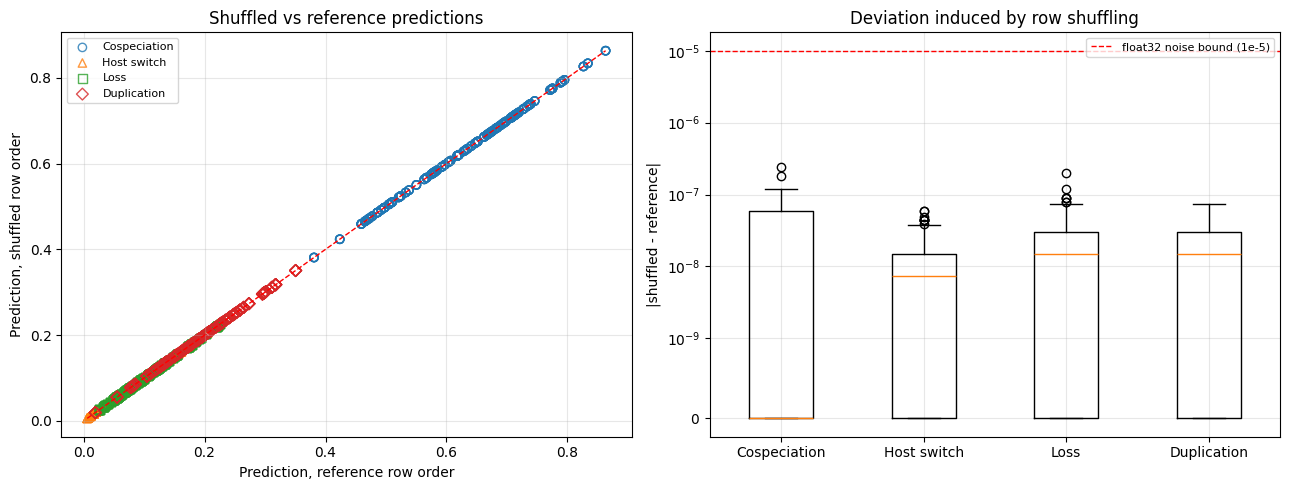

Saved: test_data/permutation_invariance.png


In [54]:
# -- Plot: reference vs shuffled predictions, and deviation spread --
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
# marker per event: readable in B&W
for e, c, mk in zip(EVENT_NAMES, ["C0", "C1", "C2", "C3"], ["o", "^", "s", "D"]):
    ax.scatter(perm_base.loc[df_dev.file, e].values, df_dev[e].values,
               s=36, alpha=0.8, marker=mk, facecolors="none", edgecolors=c, linewidths=1,
               label=disp(e))
lo = min(perm_base[EVENT_NAMES].values.min(), df_perm[EVENT_NAMES].values.min())
hi = max(perm_base[EVENT_NAMES].values.max(), df_perm[EVENT_NAMES].values.max())
ax.plot([lo, hi], [lo, hi], "r--", lw=1)
ax.set_xlabel("Prediction, reference row order")
ax.set_ylabel("Prediction, shuffled row order")
ax.set_title("Shuffled vs reference predictions")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.boxplot([abs_dev[f"dev_{e}"].values for e in EVENT_NAMES],
           labels=[disp(e) for e in EVENT_NAMES], showfliers=True)
ax.set_yscale("symlog", linthresh=1e-9)
ax.axhline(1e-5, color="r", ls="--", lw=1, label="float32 noise bound (1e-5)")
ax.set_ylabel("|shuffled - reference|")
ax.set_title("Deviation induced by row shuffling")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("test_data/permutation_invariance.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: test_data/permutation_invariance.png")

## Extra: Fox vs AmoCoala on the AsymmeTree test set

The same comparison as for treeducken, on the 100 AsymmeTree test datasets above. AsymmeTree is the simulator
Fox is trained on, so this comparison favours Fox; the treeducken comparison is the main one. Results for the
100 test datasets are in `test_data/amocoala_data_100/` (1 round) and `test_data/amocoala_small_100_N2000/`
(3 rounds); the older `old/test_data/amocoala_data/` belongs to the previous 40-dataset test set.

In [9]:
# ── AmoCoala, 1 round, all test datasets (resumable) ──
AC_DIR_1 = "test_data/amocoala_data_100"
# overnight retry of the datasets skipped at 30 min: 90 min limit each, smallest (symbiont leaves) first
n_sym_leaves = lambda p: int(re.search(r"Symbiont_num_leaves: (\d+)", open(p).read()).group(1))
run_amocoala_batch(sorted(all_tgls, key=n_sym_leaves), AC_DIR_1, n_rounds=1,
                   timeout_min=90, retry_skipped=False)

100 datasets: 80 done, 20 skipped as too slow, 0 to run (7 at a time, 90 min limit each)
AmoCoala results: 80 / 100; skipped as too slow: ['Dataset10.tgl', 'Dataset17.tgl', 'Dataset18.tgl', 'Dataset23.tgl', 'Dataset32.tgl', 'Dataset35.tgl', 'Dataset48.tgl', 'Dataset50.tgl', 'Dataset66.tgl', 'Dataset67.tgl', 'Dataset68.tgl', 'Dataset70.tgl', 'Dataset78.tgl', 'Dataset81.tgl', 'Dataset91.tgl', 'Dataset92.tgl', 'Dataset93.tgl', 'Dataset94.tgl', 'Dataset95.tgl', 'Dataset98.tgl']


In [10]:
df_cmp3_1 = amocoala_vs_fox(all_tgls, AC_DIR_1, n_rounds=1)

Matched: 80 datasets with both AmoCoala (1 round(s)) and Fox


MAE    RMSE       R²  Pearson r    Bias
Event        Method                                              
Cospeciation AmoCoala  0.1688  0.2021  -1.6841    -0.0164 -0.1551
             Fox       0.0530  0.0740   0.6399     0.8096  0.0148
Host switch  AmoCoala  0.1762  0.1832 -14.3874     0.1564  0.1759
             Fox       0.0159  0.0195   0.8255     0.9104 -0.0022
Loss         AmoCoala  0.0862  0.1055  -1.6669    -0.2293  0.0696
             Fox       0.0342  0.0467   0.4774     0.7100 -0.0083
Duplication  AmoCoala  0.0956  0.1130  -1.6512     0.2165 -0.0904
             Fox       0.0218  0.0299   0.8145     0.9051 -0.0043

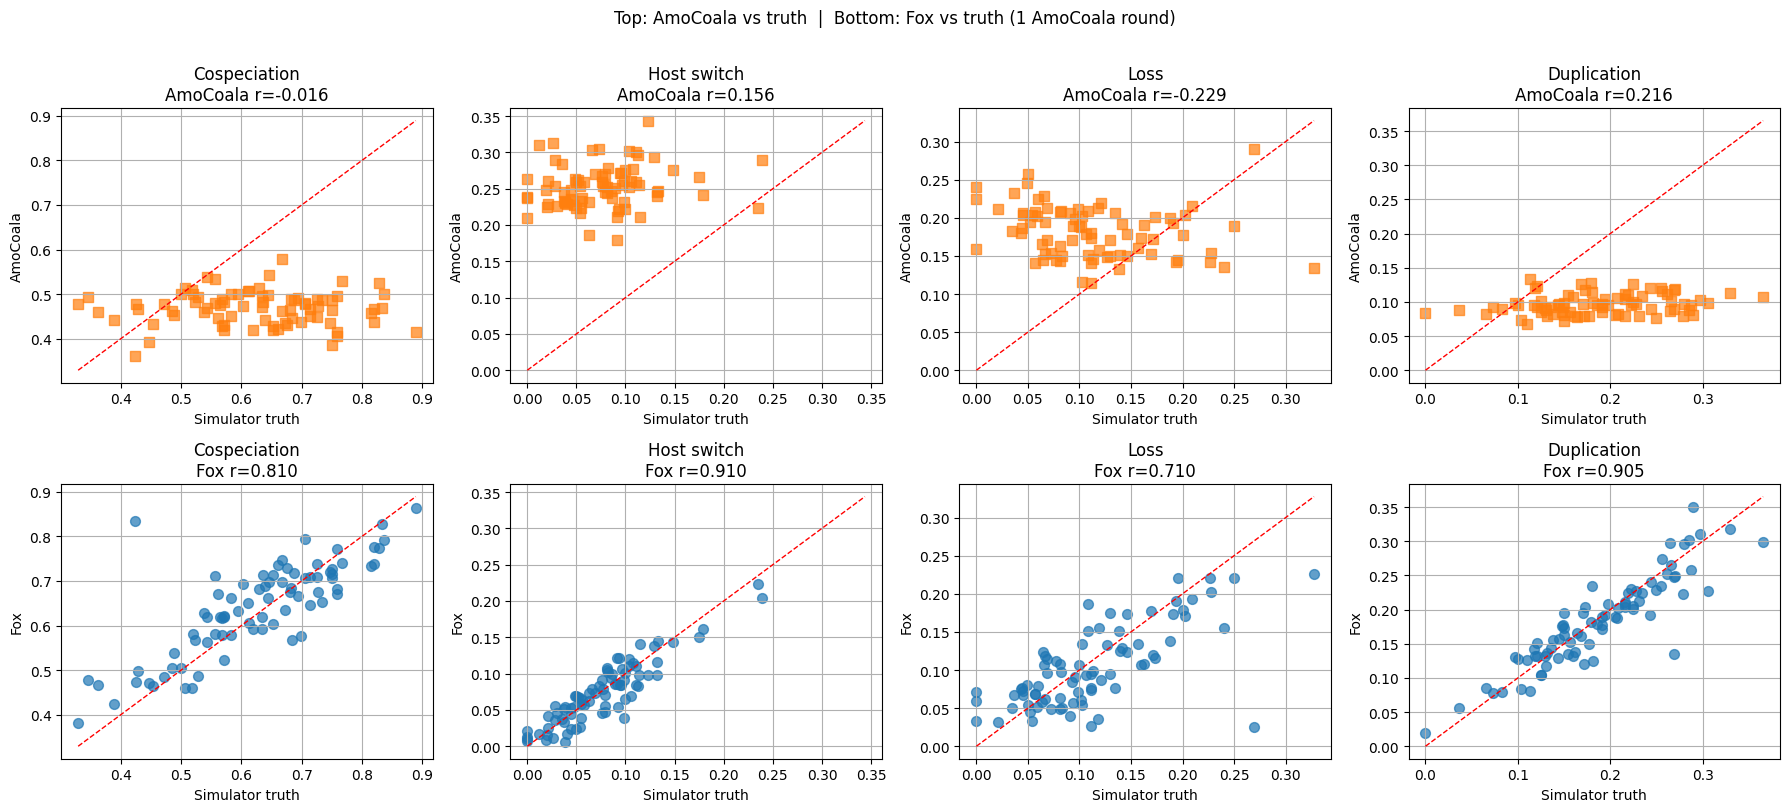

In [11]:
plot_amocoala_vs_fox(df_cmp3_1, "test_data/amocoala_vs_fox.png",
                     "Top: AmoCoala vs truth  |  Bottom: Fox vs truth (1 AmoCoala round)")

In [12]:
df_cmp3 = df_cmp3_1   # tree-size analysis uses the 1-round comparison on all datasets

### Performance vs. tree size (AsymmeTree)

Does accuracy degrade on larger trees? Scatter and binned MAE for Fox and AmoCoala across both host and parasite leaf count.

Datasets with leaf info: 80


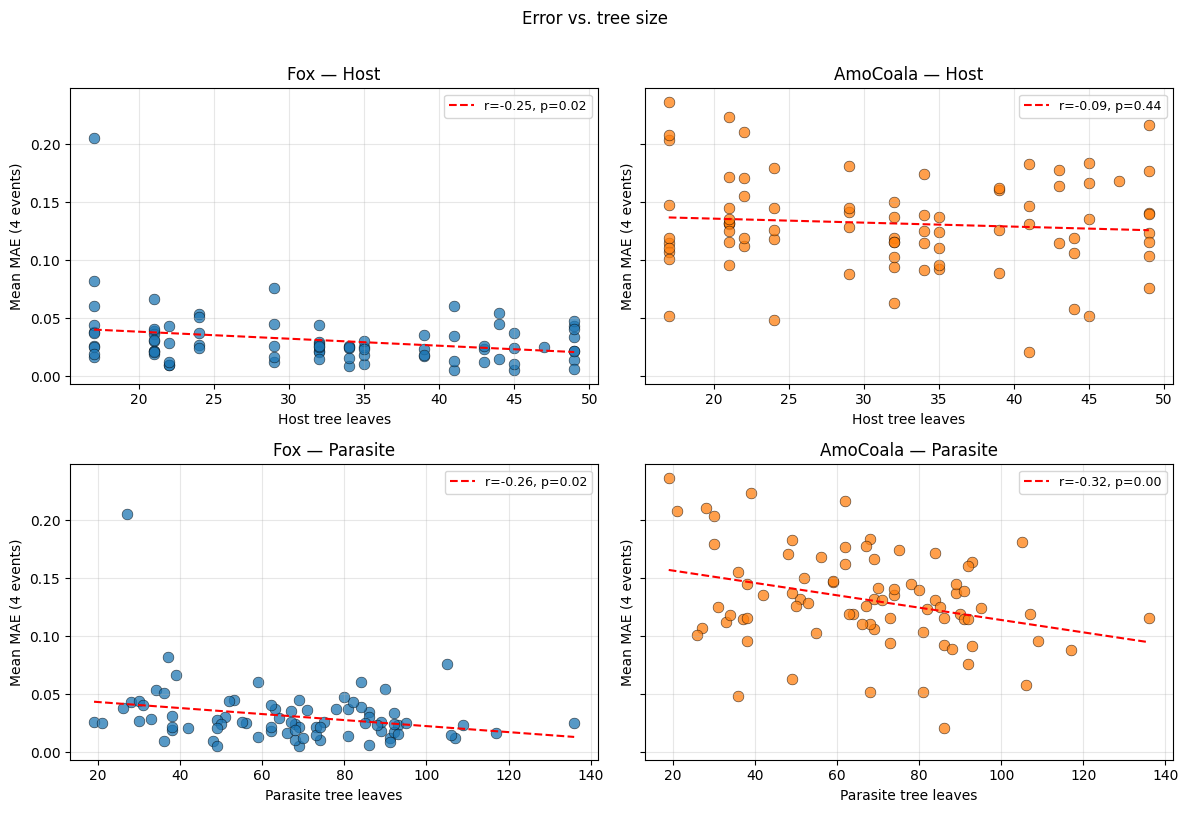


Binned MAE — Host leaves:
                  N  Fox MAE  AmoCoala MAE
Bin                                       
Small\n(≤24)     30   0.0394        0.1398
Medium\n(29–35)  23   0.0259        0.1212
Large\n(≥39)     27   0.0266        0.1317

Binned MAE — Parasite leaves:
                  N  Fox MAE  AmoCoala MAE
Bin                                       
Small\n(≤55)     27   0.0397        0.1418
Medium\n(56–80)  26   0.0262        0.1399
Large\n(≥81)     27   0.0276        0.1136


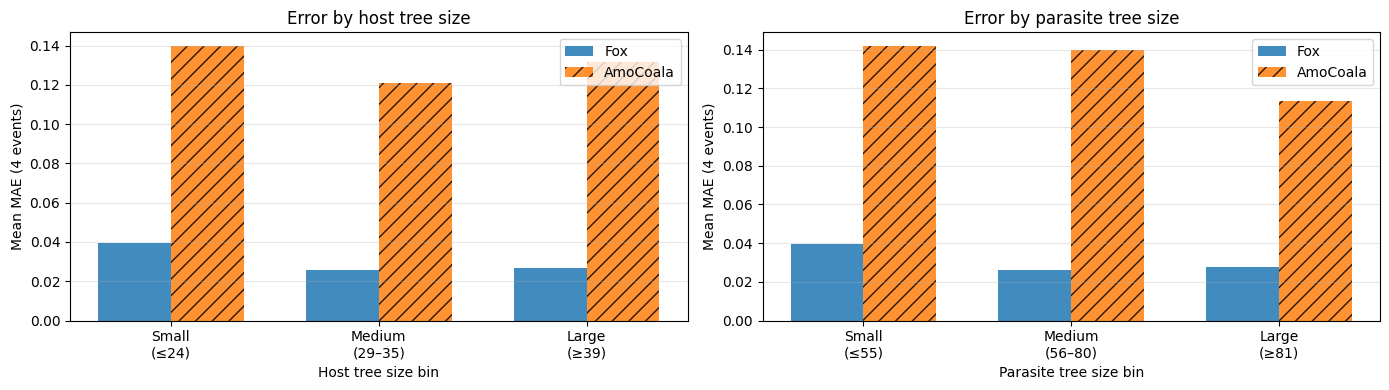

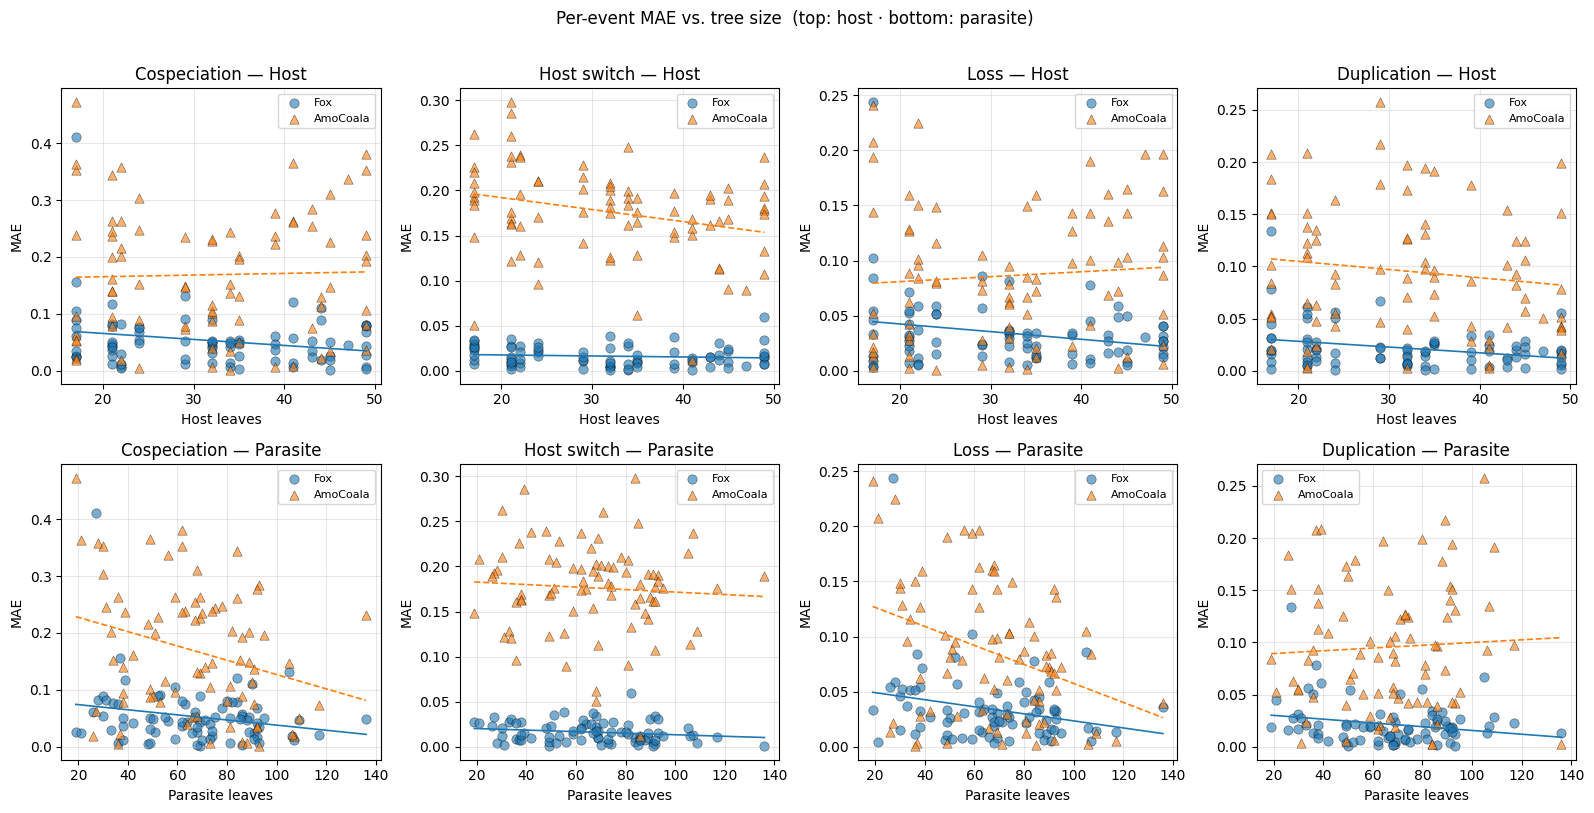

In [13]:
# ── Performance vs. tree size (host & parasite) ───────────────────────────────
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats

TGL_DIR = "test_data/Datasets"

leaf_rows = []
for tgl in sorted(__import__('glob').glob(f"{TGL_DIR}/*.tgl")):
    txt = open(tgl).read()
    h = re.search(r"Host_num_leaves: (\d+)", txt)
    s = re.search(r"Symbiont_num_leaves: (\d+)", txt)
    if h and s:
        leaf_rows.append({
            "file": __import__('os').path.basename(tgl),
            "host_leaves": int(h.group(1)),
            "sym_leaves":  int(s.group(1)),
        })

df_leaves = pd.DataFrame(leaf_rows)
df_sz = df_cmp3.merge(df_leaves, on="file", how="inner")
print(f"Datasets with leaf info: {len(df_sz)}")

for model_name, prefix in [("Fox", "pred"), ("AmoCoala", "ac")]:
    df_sz[f"mae_{model_name}"] = np.mean(
        [np.abs(df_sz[f"{prefix}_{e}"] - df_sz[f"true_{e}"]) for e in EVENT_NAMES], axis=0
    )

TREE_DIMS = [("host_leaves", "Host"), ("sym_leaves", "Parasite")]

# ── Figure 1: scatter MAE vs tree size (2 rows = host/para, 2 cols = model) ──
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
for row, (col_name, dim_label) in enumerate(TREE_DIMS):
    for ax, (model_name, color) in zip(axes[row], [("Fox", "C0"), ("AmoCoala", "C1")]):
        x = df_sz[col_name]
        y = df_sz[f"mae_{model_name}"]
        ax.scatter(x, y, alpha=0.75, s=60, color=color, edgecolors="k", linewidths=0.4)
        m, b, r, p, _ = stats.linregress(x, y)
        xl = np.array([x.min(), x.max()])
        ax.plot(xl, m * xl + b, "r--", lw=1.5, label=f"r={r:.2f}, p={p:.2f}")
        ax.set_xlabel(f"{dim_label} tree leaves")
        ax.set_ylabel("Mean MAE (4 events)")
        ax.set_title(f"{model_name} — {dim_label}")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
plt.suptitle("Error vs. tree size", y=1.01)
plt.tight_layout()
plt.savefig("test_data/error_vs_treesize_scatter.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Figure 2: binned MAE bar chart (side-by-side host / parasite) ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (col_name, dim_label) in zip(axes, TREE_DIMS):
    bins_cat = pd.qcut(df_sz[col_name], q=3, labels=["Small", "Medium", "Large"])
    bin_summary = []
    for b in bins_cat.cat.categories:
        sub = df_sz[bins_cat == b]
        lo, hi = sub[col_name].min(), sub[col_name].max()
        label = f"{b}\n(≤{hi})" if b == "Small" else (f"{b}\n(≥{lo})" if b == "Large" else f"{b}\n({lo}–{hi})")
        bin_summary.append({"Bin": label, "N": len(sub),
                             "Fox MAE": sub["mae_Fox"].mean(),
                             "AmoCoala MAE": sub["mae_AmoCoala"].mean()})
    df_bin = pd.DataFrame(bin_summary).set_index("Bin")
    print(f"\nBinned MAE — {dim_label} leaves:")
    print(df_bin.round(4))
    x_pos = np.arange(len(df_bin)); w = 0.35
    ax.bar(x_pos - w/2, df_bin["Fox MAE"],  w, label="Fox",  color="C0", alpha=0.85)
    ax.bar(x_pos + w/2, df_bin["AmoCoala MAE"], w, label="AmoCoala", color="C1", alpha=0.85,
           hatch="//", edgecolor="black", linewidth=0)  # stripes: readable in B&W
    ax.set_xticks(x_pos); ax.set_xticklabels(df_bin.index)
    ax.set_ylabel("Mean MAE (4 events)")
    ax.set_xlabel(f"{dim_label} tree size bin")
    ax.set_title(f"Error by {dim_label.lower()} tree size")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("test_data/error_vs_treesize_binned.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Figure 3: per-event MAE vs tree size (2 rows = host/para, 4 cols = event) ─
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for row, (col_name, dim_label) in enumerate(TREE_DIMS):
    for ax, event in zip(axes[row], EVENT_NAMES):
        x = df_sz[col_name]
        # marker + line style per model: readable in B&W
        for model_key, color, marker, ls, lbl in [("pred", "C0", "o", "-",  "Fox"),
                                                  ("ac",   "C1", "^", "--", "AmoCoala")]:
            y = np.abs(df_sz[f"{model_key}_{event}"] - df_sz[f"true_{event}"])
            ax.scatter(x, y, alpha=0.6, s=45, color=color, marker=marker,
                       edgecolors="k", linewidths=0.4, label=lbl)
            m, b, r, p, _ = stats.linregress(x, y)
            xl = np.array([x.min(), x.max()])
            ax.plot(xl, m * xl + b, ls, color=color, lw=1.2)
        ax.set_title(f"{disp(event)} — {dim_label}")
        ax.set_xlabel(f"{dim_label} leaves")
        ax.set_ylabel("MAE")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
plt.suptitle("Per-event MAE vs. tree size  (top: host · bottom: parasite)", y=1.01)
plt.tight_layout()
plt.savefig("test_data/error_vs_treesize_per_event.png", dpi=120, bbox_inches="tight")
plt.show()

### AmoCoala with more rounds (AsymmeTree)

The same comparison with 3 AmoCoala rounds, on the 5 smallest test datasets (by number of symbiont leaves),
since 3 rounds take several times longer.
AmoCoala keeps a share of the vectors in each round (`-t`); with 1000 vectors and 0.1 in every round only 10
are left after round 3, too few for a stable estimate. So this run samples 2000 vectors and keeps
10%, 25%, 25% (`-N 2000 -t 0.1,0.25,0.25`, as for *Heliconius* in the Extra section), leaving 50.
Results go to `test_data/amocoala_small_100_N2000/`. No time limit here: every dataset runs to the end,
including ones skipped as too slow in earlier runs.

In [14]:
# ── AmoCoala, 3 rounds, 5 datasets (resumable) ──
AC_DIR_3 = "test_data/amocoala_small_100_N2000"
AC_N_3, AC_TOL_3 = 2000, [0.1, 0.25, 0.25]   # 2000 x 0.1 x 0.25 x 0.25 = 50 vectors left after round 3
N_SMALL  = 5
n_sym = lambda p: int(re.search(r"Symbiont_num_leaves: (\d+)", open(p).read()).group(1))
small_tgls = sorted(all_tgls, key=n_sym)[:N_SMALL]   # the 5 smallest test datasets (symbiont leaves)
print("Datasets:", [os.path.basename(p) for p in small_tgls])
run_amocoala_batch(small_tgls, AC_DIR_3, n_rounds=3, timeout_min=None, retry_skipped=True,   # no time limit
                   n_sim=AC_N_3, tol=AC_TOL_3)

Datasets: ['Dataset13.tgl', 'Dataset64.tgl', 'Dataset14.tgl', 'Dataset12.tgl', 'Dataset2.tgl']
5 datasets: 5 done, 0 skipped as too slow, 0 to run (7 at a time, no time limit)
AmoCoala results: 5 / 5; skipped as too slow: []


In [15]:
df_cmp3_3 = amocoala_vs_fox(small_tgls, AC_DIR_3, n_rounds=3)

Matched: 5 datasets with both AmoCoala (3 round(s)) and Fox


MAE    RMSE       R²  Pearson r    Bias
Event        Method                                              
Cospeciation AmoCoala  0.1595  0.1840  -0.0696     0.4298 -0.0873
             Fox       0.1206  0.1899  -0.1390     0.2852  0.0681
Host switch  AmoCoala  0.1741  0.1834 -41.1179     0.0389  0.1741
             Fox       0.0227  0.0247   0.2370     0.9385 -0.0227
Loss         AmoCoala  0.0995  0.1090  -0.0880     0.4279  0.0490
             Fox       0.0790  0.1158  -0.2276    -0.0142 -0.0401
Duplication  AmoCoala  0.1469  0.1733  -1.9046    -0.3589 -0.1357
             Fox       0.0483  0.0654   0.5866     0.7751 -0.0053

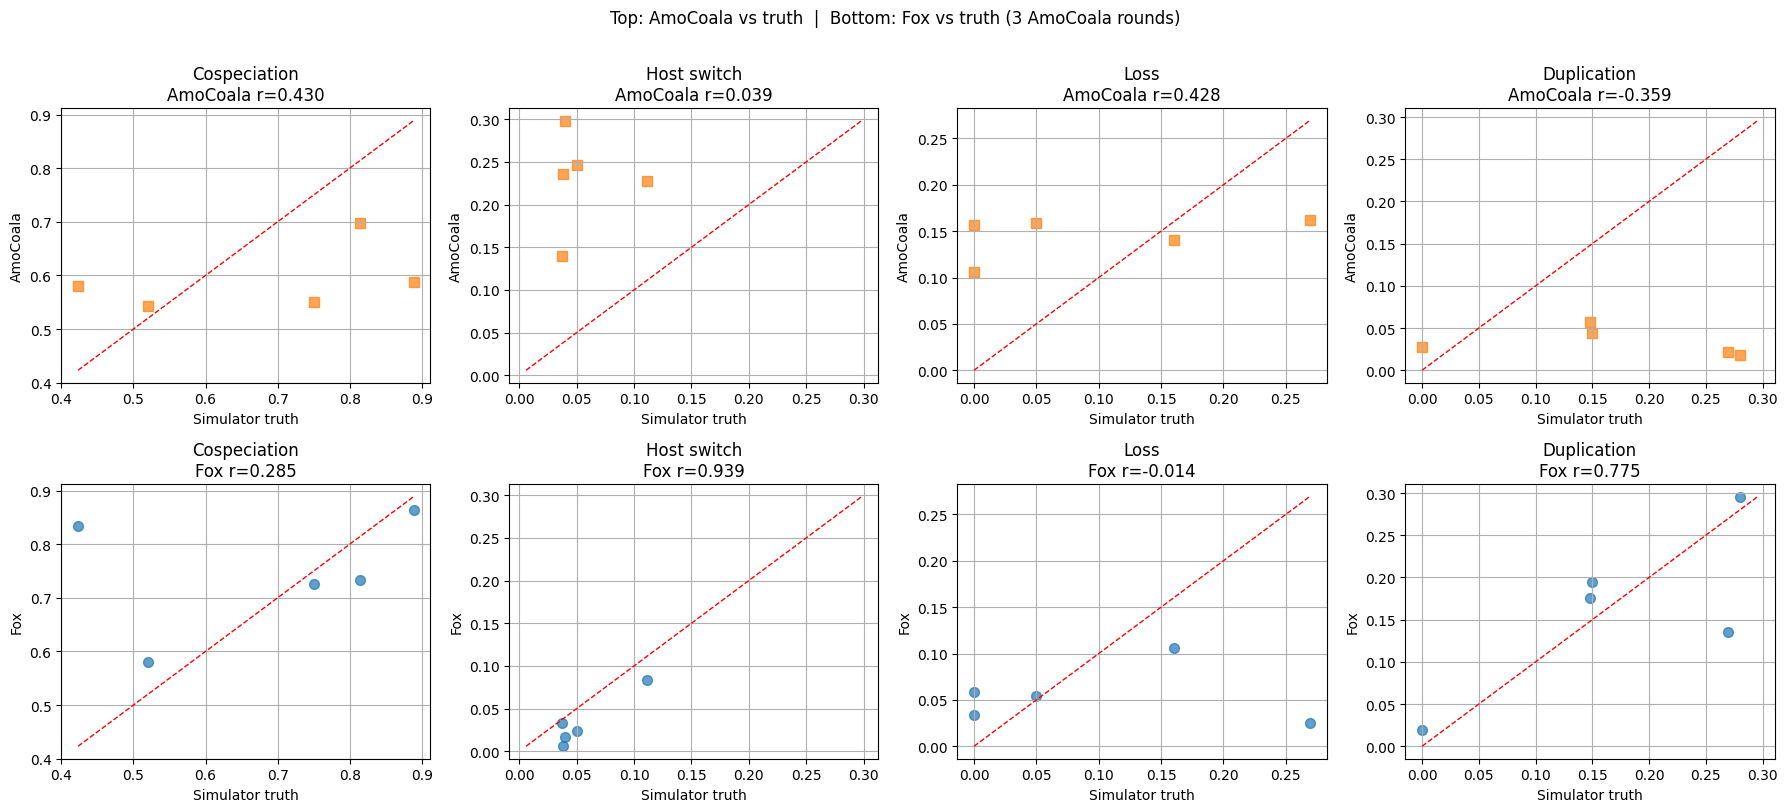

In [16]:
plot_amocoala_vs_fox(df_cmp3_3, "test_data/amocoala_vs_fox_3rounds.png",
                     "Top: AmoCoala vs truth  |  Bottom: Fox vs truth (3 AmoCoala rounds)")

## Extra: *Heliconius* Müllerian mimicry

Kept as an extra rather than a main test. At the protein level these sequences carry almost no signal for Fox
(1 variable host column in the 250 columns Fox reads, and `Hmelp246` is all gaps in that window), and the
system is a mimicry pair rather than a host-symbiont one, so there is no known truth to score against.
AmoCoala reads the published trees instead, so the two tools do not see comparable inputs. The cockroach /
*Blattabacterium* section above is the main real-data test.

### Fox vs AmoCoala on *Heliconius*

The published alignment is mitochondrial DNA (COI + COII). Fox reads amino acids, so the sequences are
translated first (invertebrate mitochondrial code, reading frame picked automatically):
`python -m fox.translate test_data/real_data/extra/heliconius_mimicry.tgl test_data/real_data/extra/heliconius_mimicry_aa.tgl --table 5`.
AmoCoala uses the trees in `heliconius.nex`, so it is unaffected.

At the protein level these sequences are almost identical (the host alignment has 1 variable column in the
250 Fox reads), far less divergent than the training data, so Fox has very little signal here.

In [ ]:
# ── 1. Show dataset contents ──────────────────────────────────────────────────
import pandas as pd

TGL_PATH = "test_data/real_data/extra/heliconius_mimicry_aa.tgl"   # protein; original DNA: heliconius_mimicry.tgl
NEX_PATH = "test_data/real_data/extra/heliconius.nex"
MAP_PATH = "test_data/real_data/extra/heliconius_specimen_map.xlsx"

d = parse_tgl(TGL_PATH)
host_msa  = d["host_msa"]
para_msa  = d["para_msa"]
dist_pairs = d["distribution"]

# Specimen cross-reference
spec_map = pd.read_excel(MAP_PATH)
short_to_fig = dict(zip(spec_map["Short_name"], spec_map["Name_figure"]))

print("HOST (H. erato)")
for s in host_msa:
    print(f"  {s:12s}  {short_to_fig.get(s,'')}")

print()
print("PARASITE (H. melpomene) ")
for s in para_msa:
    print(f"  {s:12s}  {short_to_fig.get(s,'')}")

print()
print("Associations")
for p, h in dist_pairs:
    print(f"  {p:12s} : {h:12s}   {short_to_fig.get(p,''):25s} ↔ {short_to_fig.get(h,'')}")

HOST (H. erato)
  Herato25      emma (East Pe)
  Herato48      favorinus (East Pe)
  Herato38      etylus (East E)
  Herato75      lativitta (East E)
  Herato30      erato (East FG)
  Herato61      hydara (East FG)
  Herato69      hydara (East T)
  Herato65      hydara (West Pa)
  Herato81      petiverana (West CR)
  Herato87      petiverana (West Pa)
  Herato56      hydara (East C)
  Herato21      cyrbia (West E)

PARASITE (H. melpomene) 
  Hmelpo98      aglaope (East Pe)
  Hmelp102      amaryllis (East Pe)
  Hmelp110      ecuadoriensis (East E)
  Hmelp246      malleti (East E)
  Hmelp161      thelxiopeia (East FG)
  Hmelp129      melpomene (East FG)
  Hmelp168      melpomene (East T)
  Hmelp132      melpomene (West Pa)
  Hmelp136      rosina (West CR)
  Hmelp133      rosina (West Pa)
  Hmelp100      melpomene (East C)
  Hmelp134      cythera (West E)

Associations
  Hmelp134     : Herato21       cythera (West E)          ↔ cyrbia (West E)
  Hmelp136     : Herato81       rosina (West 

In [ ]:
# ── 3a. Fox prediction ────────────────────────────────────────────────────
import torch

host_tok = torch.stack([encode_sequence(seq) for seq in host_msa.values()])
para_tok = torch.stack([encode_sequence(seq) for seq in para_msa.values()])
host_dist_t = jukes_cantor_dist(host_tok)
para_dist_t = jukes_cantor_dist(para_tok)
h_idx2 = {n: i for i, n in enumerate(host_msa)}
p_idx2 = {n: i for i, n in enumerate(para_msa)}
mappings = [(h_idx2[h], p_idx2[p]) for p, h in dist_pairs if p in p_idx2 and h in h_idx2]

with torch.no_grad():
    out = model(
        host_tok.unsqueeze(0).to(device),
        para_tok.unsqueeze(0).to(device),
        [mappings],
        host_dist=host_dist_t.unsqueeze(0).to(device),
        para_dist=para_dist_t.unsqueeze(0).to(device),
    )

fox_pred = dict(zip(EVENT_NAMES, out.squeeze(0).cpu().tolist()))
print("Fox prediction on Heliconius mimicry dataset:")
print(f"  {'Event':12s}  {'Prediction':>10s}")
print(f"  {'-'*25}")
for e, v in fox_pred.items():
    print(f"  {e:12s}  {v:10.4f}")
print(f"\n  Dominant signal: {max(fox_pred, key=fox_pred.get)} ({max(fox_pred.values()):.1%})")

Fox prediction on Heliconius mimicry dataset:
  Event         Prediction
  -------------------------
  Speciation        0.3596
  HGT               0.0965
  Loss              0.2144
  Duplication       0.3295

  Dominant signal: Speciation (36.0%)


In [ ]:
# ── 3b. AmoCoala on heliconius.nex ───────────────────────────────────────────
import subprocess, os

AMOCOALA_JAR = os.environ.get("AMOCOALA_JAR", "/Users/gabriele/AmoCoala-main/AmoCoala.jar")
NEX = "test_data/real_data/extra/heliconius.nex"
R = 3
AC_CSV = NEX + f".accep.round_{R}.csv"

if not os.path.exists(AC_CSV):
    print("Running AmoCoala...")
    r = subprocess.run(
        f'java -jar {AMOCOALA_JAR} -input {NEX} -N 2000 -M 100 -R {R} -t 0.1,0.25,0.25',
        shell=True, capture_output=True, text=True, timeout=6000
    )
    print(r.stdout[-500:] if r.stdout else "")
    print(r.stderr[-500:] if r.stderr else "")
else:
    print(f"Reusing existing result: {AC_CSV}")

# Parse AmoCoala result (final round = posterior)
if os.path.exists(AC_CSV):
    rows = []
    with open(AC_CSV) as f:
        for line in f:
            vals = [float(x) for x in line.strip().split("\t") if x.strip()]
            if len(vals) >= 4:
                rows.append(vals)
    arr = np.array(rows)
    cospec, dup, hsw, loss = arr[:,0].mean(), arr[:,1].mean(), arr[:,2].mean(), arr[:,3].mean()
    total = cospec + dup + hsw + loss or 1.0
    ac_pred = {
        "Speciation":  cospec / total,
        "HGT":         hsw    / total,
        "Loss":        loss   / total,
        "Duplication": dup    / total,
    }
    print(f"\nAmoCoala result ({len(rows)} accepted solutions, round {R}):")
    print(f"  {'Event':12s}  {'Prediction':>10s}")
    print(f"  {'-'*25}")
    for e, v in ac_pred.items():
        print(f"  {e:12s}  {v:10.4f}")
    print(f"\n  Dominant signal: {max(ac_pred, key=ac_pred.get)} ({max(ac_pred.values()):.1%})")
else:
    ac_pred = None
    print("AmoCoala did not produce output.")

Reusing existing result: test_data/real_data/heliconius.nex.accep.round_3.csv

AmoCoala result (50 accepted solutions, round 3):
  Event         Prediction
  -------------------------
  Speciation        0.6076
  HGT               0.1576
  Loss              0.2111
  Duplication       0.0236

  Dominant signal: Speciation (60.8%)


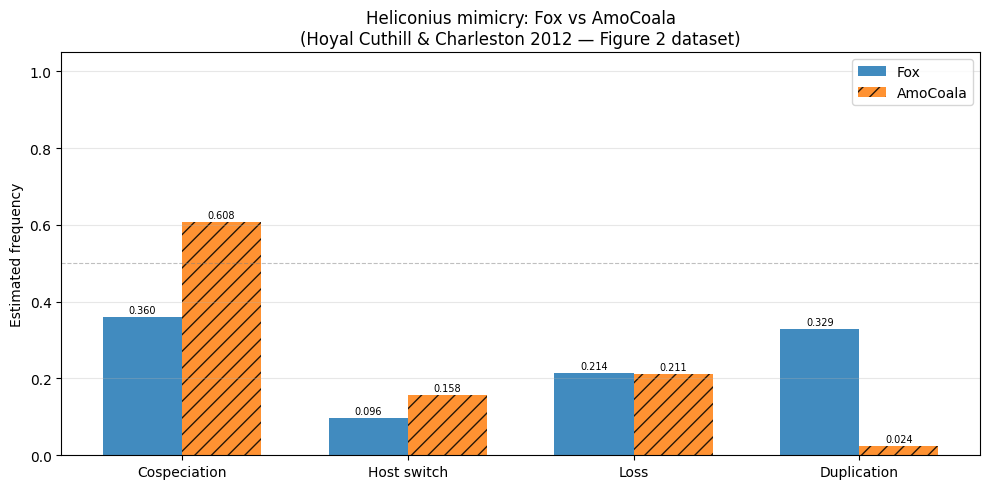

Saved: test_data/heliconius_fox_vs_amocoala.png

Summary:
  Event              Fox  AmoCoala
  --------------------------------
  Speciation      0.3596    0.6076
  HGT             0.0965    0.1576
  Loss            0.2144    0.2111
  Duplication     0.3295    0.0236

  Expected: tools should agree on high Speciation
  (parallel cospeciation = textbook case for this dataset)


In [ ]:
# ── 4. Compare Fox vs AmoCoala on real Heliconius data ──
import matplotlib.pyplot as plt
import numpy as np

if ac_pred is None:
    print("AmoCoala result not available — skipping comparison.")
else:
    events = EVENT_NAMES
    x = np.arange(len(events))
    w = 0.35
    series = [
        ("Fox",      fox_pred, "C0", -w/2, None),
        ("AmoCoala", ac_pred,  "C1",  w/2, "//"),  # stripes: readable in B&W
    ]

    fig, ax = plt.subplots(figsize=(10, 5))
    for name, pred, color, off, hatch in series:
        bars = ax.bar(x + off, [pred[e] for e in events], w,
                      label=name, color=color, alpha=0.85,
                      hatch=hatch, edgecolor="black", linewidth=0)
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.005, f"{h:.3f}",
                    ha="center", va="bottom", fontsize=7)

    ax.set_xticks(x); ax.set_xticklabels([disp(e) for e in events])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Estimated frequency")
    ax.set_title("Heliconius mimicry: Fox vs AmoCoala\n"
                 "(Hoyal Cuthill & Charleston 2012 — Figure 2 dataset)")
    ax.legend()
    ax.axhline(0.5, color="gray", lw=0.8, ls="--", alpha=0.5)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("test_data/real_data/extra/heliconius_fox_vs_amocoala.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved: test_data/real_data/extra/heliconius_fox_vs_amocoala.png")

    # ── Summary table ──────────────────────────────────────────────────────────
    print("\nSummary:")
    print(f"  {'Event':12s}  {'Fox':>8s}  {'AmoCoala':>8s}")
    print(f"  {'-'*32}")
    for e in events:
        print(f"  {e:12s}  {fox_pred[e]:8.4f}  {ac_pred[e]:8.4f}")
    print()
    print("  Expected: tools should agree on high Speciation")
    print("  (parallel cospeciation = textbook case for this dataset)")

### Leaf-removal experiment: dropping Hmelp246

One symbiont specimen (*H. melpomene malleti*, `Hmelp246`, East Ecuador) is ~76% gaps
over the full alignment and 100% gaps within the first 250 columns Fox reads
(`MAX_SEQ_LEN = 250`), so it carries no phylogenetic signal. We drop it and re-run
**both** Fox and AmoCoala to see whether the cospeciation-dominated profile sharpens,
and whether the effect is specific to Fox's fixed input window or reflects the
specimen itself.

In [ ]:
# -- Leaf-removal: Fox WITHOUT the Hmelp246 <-> its host association pair --
DROP = "Hmelp246"
DROP_HOST = next(h for (p, h) in dist_pairs if p == DROP)   # = Herato75
print(f"Removing association pair: {DROP} <-> {DROP_HOST}")

para_msa_nl   = {k: v for k, v in para_msa.items() if k != DROP}
host_msa_nl   = {k: v for k, v in host_msa.items() if k != DROP_HOST}
dist_pairs_nl = [(p, h) for (p, h) in dist_pairs if p != DROP and h != DROP_HOST]

host_tok_nl = torch.stack([encode_sequence(seq) for seq in host_msa_nl.values()])
para_tok_nl = torch.stack([encode_sequence(seq) for seq in para_msa_nl.values()])
host_dist_nl = jukes_cantor_dist(host_tok_nl)
para_dist_nl = jukes_cantor_dist(para_tok_nl)
h_idx_nl = {n: i for i, n in enumerate(host_msa_nl)}
p_idx_nl = {n: i for i, n in enumerate(para_msa_nl)}
map_nl = [(h_idx_nl[h], p_idx_nl[p]) for p, h in dist_pairs_nl if p in p_idx_nl and h in h_idx_nl]

with torch.no_grad():
    out_nl = model(
        host_tok_nl.unsqueeze(0).to(device),
        para_tok_nl.unsqueeze(0).to(device),
        [map_nl],
        host_dist=host_dist_nl.unsqueeze(0).to(device),
        para_dist=para_dist_nl.unsqueeze(0).to(device),
    )
fox_pred_nl = dict(zip(EVENT_NAMES, out_nl.squeeze(0).cpu().tolist()))
print(f"Fox WITHOUT {DROP} (+ host {DROP_HOST}):")
for e, v in fox_pred_nl.items():
    print(f"  {e:12s}  {v:10.4f}")
print(f"\n  Dominant: {max(fox_pred_nl, key=fox_pred_nl.get)} "
      f"({max(fox_pred_nl.values()):.1%})")

Removing association pair: Hmelp246 <-> Herato75
Fox WITHOUT Hmelp246 (+ host Herato75):
  Speciation        0.0000
  HGT               0.7600
  Loss              0.2387
  Duplication       0.0012

  Dominant: HGT (76.0%)


In [ ]:
# -- Auto-build the pruned .nex for AmoCoala (no extra dependencies) --
# Removes the whole association pair: the parasite leaf Hmelp246 AND its host.
import re

SRC_NEX = "test_data/real_data/extra/heliconius.nex"
NEX_NL  = "test_data/real_data/extra/filtered/heliconius_no_Hmelp246.nex"
DROP    = "Hmelp246"

def _parse_newick(s):
    s = s.strip().rstrip(";"); pos = 0
    def parse():
        nonlocal pos
        if s[pos] == "(":
            pos += 1; kids = []
            while True:
                kids.append(parse())
                if s[pos] == ",": pos += 1
                elif s[pos] == ")": pos += 1; break
            return kids
        start = pos
        while pos < len(s) and s[pos] not in ",()": pos += 1
        return s[start:pos]
    return parse()

def _prune(node, drop):
    if isinstance(node, str):
        return None if node == drop else node
    kids = [k for k in (_prune(c, drop) for c in node) if k is not None]
    if not kids: return None
    if len(kids) == 1: return kids[0]        # collapse unary node
    return kids

def _to_newick(node):
    if isinstance(node, str): return node
    return "(" + ",".join(_to_newick(c) for c in node) + ")"

raw  = open(SRC_NEX).read()
host = re.search(r"TREE\s+HOST\s*=\s*(.+?);", raw, re.S).group(1).strip()
par  = re.search(r"TREE\s+PARASITE\s*=\s*(.+?);", raw, re.S).group(1).strip()
rng  = re.search(r"RANGE\s*(.+?);", raw, re.S).group(1)

pairs     = [p.strip() for p in rng.split(",") if p.strip()]
DROP_HOST = next(p.split(":")[1].strip() for p in pairs if p.split(":")[0].strip() == DROP)
print(f"Removing association pair: {DROP} <-> {DROP_HOST}")

par_pruned  = _to_newick(_prune(_parse_newick(par),  DROP))
host_pruned = _to_newick(_prune(_parse_newick(host), DROP_HOST))

pairs_nl = [p for p in pairs
            if p.split(":")[0].strip() != DROP and p.split(":")[1].strip() != DROP_HOST]
range_nl = ",\n\t\t".join(pairs_nl)

nex = (
    "#NEXUS\n"
    "BEGIN HOST;\n"
    f"\tTREE HOST = {host_pruned};\n"
    "ENDBLOCK;\n"
    "BEGIN PARASITE;\n"
    f"\tTREE PARASITE = {par_pruned};\n"
    "ENDBLOCK;\n"
    "BEGIN DISTRIBUTION;\n"
    f"\tRANGE\n\t\t{range_nl};\n"
    "ENDBLOCK;\n"
)
open(NEX_NL, "w").write(nex)
assert DROP not in nex and DROP_HOST not in nex, "a dropped taxon is still present!"
print(f"Wrote {NEX_NL}  ({len(pairs_nl)} associations; {DROP} and {DROP_HOST} removed)\n")
print(nex)

Removing association pair: Hmelp246 <-> Herato75
Wrote test_data/real_data/filtered/heliconius_no_Hmelp246.nex  (11 associations; Hmelp246 and Herato75 removed)

#NEXUS
BEGIN HOST;
	TREE HOST = (((Herato25,(Herato48,Herato38)),(Herato30,Herato61)),((((Herato69,Herato65),Herato81),Herato87),(Herato56,Herato21)));
ENDBLOCK;
BEGIN PARASITE;
	TREE PARASITE = ((((Hmelpo98,Hmelp102),Hmelp110),((Hmelp161,Hmelp129),Hmelp168)),(((Hmelp132,Hmelp136),Hmelp133),(Hmelp100,Hmelp134)));
ENDBLOCK;
BEGIN DISTRIBUTION;
	RANGE
		Hmelp134 : Herato21,
		Hmelp136 : Herato81,
		Hmelp133 : Herato87,
		Hmelp132 : Herato65,
		Hmelp100 : Herato56,
		Hmelp168 : Herato69,
		Hmelp129 : Herato61,
		Hmelp161 : Herato30,
		Hmelpo98 : Herato25,
		Hmelp102 : Herato48,
		Hmelp110 : Herato38;
ENDBLOCK;



In [ ]:
# -- Leaf-removal: AmoCoala WITHOUT Hmelp246 --
AMOCOALA_JAR = os.environ.get("AMOCOALA_JAR", "/Users/gabriele/AmoCoala-main/AmoCoala.jar")
# The pruned .nex is created automatically by the previous cell; this one just
# runs AmoCoala on it and parses the result (same settings as the full run).
NEX_NL   = "test_data/real_data/extra/filtered/heliconius_no_Hmelp246.nex"
R        = 3
AC_CSV_NL = NEX_NL + f".accep.round_{R}.csv"

ac_pred_nl = None
if os.path.exists(NEX_NL):
    if not os.path.exists(AC_CSV_NL):
        print("Running AmoCoala (no Hmelp246)...")
        r = subprocess.run(
            f'java -jar {AMOCOALA_JAR} -input {NEX_NL} -N 2000 -M 100 -R {R} -t 0.1,0.25,0.25',
            shell=True, capture_output=True, text=True, timeout=6000)
        print(r.stdout[-500:] if r.stdout else "")
        print(r.stderr[-300:] if r.stderr else "")
    if os.path.exists(AC_CSV_NL):
        rows = []
        with open(AC_CSV_NL) as f:
            for line in f:
                vals = [float(x) for x in line.strip().split("\t") if x.strip()]
                if len(vals) >= 4:
                    rows.append(vals)
        arr = np.array(rows)
        cospec, dup, hsw, loss = arr[:,0].mean(), arr[:,1].mean(), arr[:,2].mean(), arr[:,3].mean()
        tot = cospec + dup + hsw + loss or 1.0
        ac_pred_nl = {"Speciation": cospec/tot, "HGT": hsw/tot,
                      "Loss": loss/tot, "Duplication": dup/tot}
        print(f"AmoCoala WITHOUT Hmelp246 ({len(rows)} solutions):")
        for e, v in ac_pred_nl.items():
            print(f"  {e:12s}  {v:10.4f}")
else:
    print(f"Pruned .nex not found: {NEX_NL}\nCreate it, then re-run this cell.")

AmoCoala WITHOUT Hmelp246 (50 solutions):
  Speciation        0.7512
  HGT               0.1152
  Loss              0.1120
  Duplication       0.0215


In [ ]:
# -- Leaf-removal comparison: Fox / AmoCoala, with vs without Hmelp246 --
def _row(name, p):
    if p is None:
        return f"  {name:24s}  " + "     n/a" * len(EVENT_NAMES)
    return f"  {name:24s}  " + "".join(f"{p[e]:8.4f}" for e in EVENT_NAMES)

print(f"  {'':24s}  " + "".join(f"{disp(e):>8s}" for e in EVENT_NAMES))
print("  " + "-" * 56)
print(_row("Fox (full)",            fox_pred))
print(_row("Fox (no Hmelp246)",     fox_pred_nl))
print(_row("AmoCoala (full)",       ac_pred))
print(_row("AmoCoala (no Hmelp246)", ac_pred_nl))

                            CospeciationHost switch    LossDuplication
  --------------------------------------------------------
  Fox (full)                  0.3596  0.0965  0.2144  0.3295
  Fox (no Hmelp246)           0.0000  0.7600  0.2387  0.0012
  AmoCoala (full)             0.6076  0.1576  0.2111  0.0236
  AmoCoala (no Hmelp246)      0.7512  0.1152  0.1120  0.0215


### Permutation invariance on *Heliconius*

The row-order check from the permutation-invariance section, run on the *Heliconius* data.

In [ ]:
# -- Same check on the real Heliconius dataset (same shuffle contract) --
rng_real = torch.Generator(); rng_real.manual_seed(123467890)

def _shuffled_real(shuffle: bool):
    h_ids, p_ids = list(host_msa), list(para_msa)
    if shuffle:
        h_ids = [h_ids[i] for i in torch.randperm(len(h_ids), generator=rng_real)]
        p_ids = [p_ids[i] for i in torch.randperm(len(p_ids), generator=rng_real)]
    ht = torch.stack([encode_sequence(host_msa[i]) for i in h_ids])
    pt = torch.stack([encode_sequence(para_msa[i]) for i in p_ids])
    hi = {n: i for i, n in enumerate(h_ids)}
    pi = {n: i for i, n in enumerate(p_ids)}
    maps = [(hi[h], pi[p]) for p, h in dist_pairs if p in pi and h in hi]
    return fox_forward(ht, pt, jukes_cantor_dist(ht), jukes_cantor_dist(pt), maps)

rows_real = [{"perm": "reference",
              **{e: v for e, v in zip(EVENT_NAMES, _shuffled_real(False))}}]
for k in range(1, 6):
    rows_real.append({"perm": f"shuffle {k}",
                      **{e: v for e, v in zip(EVENT_NAMES, _shuffled_real(True))}})

df_real_perm = pd.DataFrame(rows_real).set_index("perm")
print(df_real_perm.to_string(float_format=lambda v: f"{v:.6f}"))
worst_real = (df_real_perm - df_real_perm.loc["reference"]).abs().values.max()
print(f"\nWorst absolute deviation (Heliconius): {worst_real:.3e}")

           Speciation      HGT     Loss  Duplication
perm                                                
reference    0.359620 0.096463 0.214432     0.329485
shuffle 1    0.359620 0.096463 0.214432     0.329485
shuffle 2    0.359620 0.096463 0.214432     0.329485
shuffle 3    0.359620 0.096463 0.214432     0.329485
shuffle 4    0.359620 0.096463 0.214432     0.329485
shuffle 5    0.359619 0.096463 0.214432     0.329485

Worst absolute deviation (Heliconius): 2.086e-07
